# Dark-matter quantum-sensor response analysis

Forward + inverse analysis of the detector response, organised **by detector**
and, within each, **by velocity-distribution model**. Same pipeline throughout
(load Mathematica response matrix -> forward model `exposure * M @ eta` ->
recover the monotone non-negative flux `x(v_min)`); only two things change:

- **detector** (`material`): **TES (Al)** -- Mermin, 0.1 eV threshold, fine `R10`;
  **MKID (TiN)** -- Lindhard, 0.2 eV threshold, fine `R9`.
- **velocity model**: **Halo** -- standard halo (SHM, `v0=238, ve=250, vesc=544`
  km/s); **pure dark disk** -- same DM density, colder (`v0=70, ve=100,
  vesc=694`). The actual **best-fit uses a mixture** `eta = (1-p)*Halo + p*Disk`
  with disk fraction `p`; because both components carry the same local DM
  density, the mixture's density equals 100% SHM for any `p`. A third model,
  **Bound** (Earth-captured thermal DM), is a separate dense population
  (`rho_b`, isotropic, `vesc=11.2` km/s) -- only the heaviest mass (1 GeV) has
  any signal, since the bound DM is too slow to reach higher `v_min`.

The mixture sections sweep `p` over `DISK_FRACTIONS` and overlay, on each fit,
the **100% SHM** halo and the **`p` x pure disk** component for reference.


In [40]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

MASS_LABELS = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
DETECTOR = {'Al': 'TES', 'TiN': 'MKID'}
# Dark-disk mixing fractions p for the best-fit eta = (1-p)*Halo + p*Disk.
DISK_FRACTIONS = (0.05, 0.25)


def run_masses(material, q='0', nbins=5, eta='Halo', background='none',
               disk_fraction=None, masses=('1', '2', '3'), solver='osqp', save=True):
    """Run the forward+inverse analysis for several DM masses.

    Shows one combined figure (the masses side by side). When ``save=True``
    (default) each run is ALSO saved on its own -- flux.csv plus an individual
    flux.pdf -- into its per-run folder
    results/<DET>/bkg-<background>/<material>_q<q>_M<mass>_R<nbins>_<eta>/, so
    every type is stored separately regardless of the combined display.
    """
    fig, axes = plt.subplots(1, len(masses), figsize=(6 * len(masses), 5), squeeze=False)
    for ax, mass in zip(axes[0], masses):
        a = DarkMatterQuantumAnalysis(
            RunConfig(material=material, q=q, mass=mass, nbins=nbins,
                      eta=eta, disk_fraction=disk_fraction, background=background))
        flux = a.optimize(solver=solver)
        print('signal     :', a.signal)
        print('background :', a.background)

        if save:
            a.save_flux()                     # flux.csv in this run's own folder
            sfig, sax = plt.subplots(figsize=(8, 6))
            a.plot(save=True, ax=sax)         # individual flux.pdf next to the CSV
            plt.close(sfig)                   # keep only the combined figure on screen

        a.plot(save=False, ax=ax)             # combined panel (display only)
        ax.set_title(f'{material} ({DETECTOR[material]}), $m_\\chi$ = {MASS_LABELS[mass]}',
                     fontsize=13)
        print(f'{material} q{q} M{mass} R{nbins}: {a.n_ebins} E-bins x '
              f'{a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
    model = eta if disk_fraction is None else f'mix {round(disk_fraction*100)}% disk'
    fig.suptitle(f'{material} ({DETECTOR[material]}), q{q}, R{nbins}, {model}, bkg={background}',
                 fontsize=14)
    plt.tight_layout(); plt.show()


# TES (Al)

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [1638.28949442 3228.46030156 4712.45547363 6136.88911964 7464.50861301]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_Halo/flux.pdf
Al q0 M1 R5: 5 E-bins x 143 v_min bins, peak flux 7.94e-31
signal     : [165.50434115 330.66231359 485.24686812 646.01832989 787.26601474]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/flux.pdf
Al q0 M2 R5: 5 E-bins x 68 v_min bins, peak flux 8.26e-32
signal     : [15.80653893 32.36907114 47.57155808 63.81815455 79.81731255]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Halo/flux.pdf
Al q0 M3 R5: 5 E-bins x 71 v_min bins, peak flux 8.28e-33


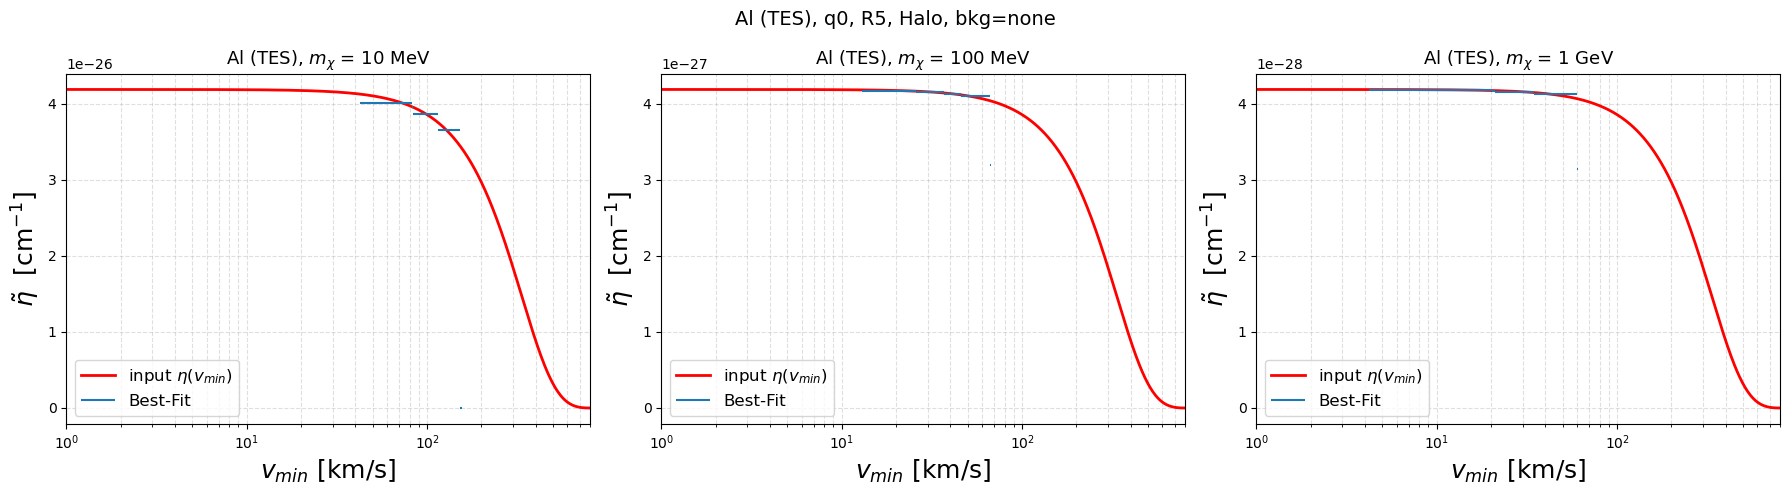

In [41]:
run_masses('Al', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [2102.59752587 3778.58409254 5067.09109339 6038.02092852 6756.88911179]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_Halo/flux.pdf
Al q2 M1 R5: 5 E-bins x 880 v_min bins, peak flux 8.00e-31
signal     : [197.60051565 361.84362849 492.41127339 595.66145275 675.32164492]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_Halo/flux.pdf
Al q2 M2 R5: 5 E-bins x 915 v_min bins, peak flux 8.25e-32
signal     : [19.59742842 35.96080442 49.00518483 59.36576824 67.40718164]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Halo/flux.pdf
Al q2 M3 R5: 5 E-bins x 926 v_min bins, peak flux 8.29e-33


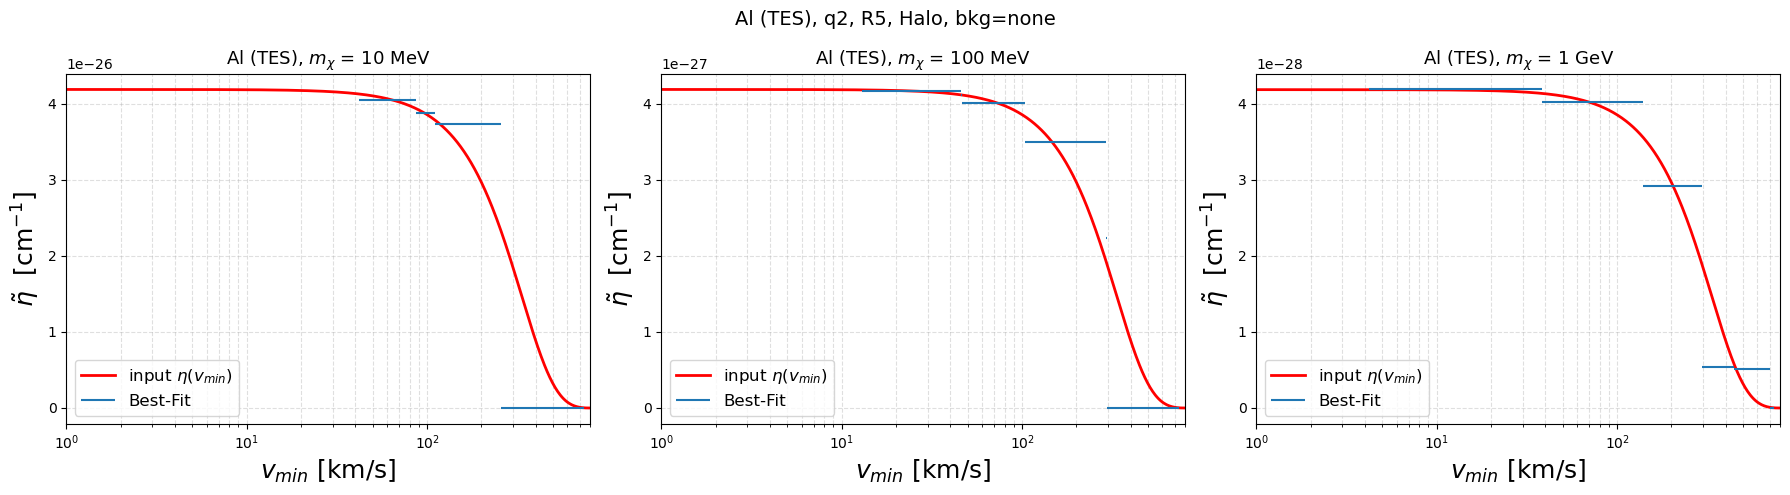

In [42]:
run_masses('Al', q='2', nbins=5, eta='Halo', solver = 'scipy')

### Heavy mediator (q0), 10 energy bins

signal     : [ 638.66595261 1080.15131907 1488.067165   1891.09428042 2282.09178064
 2664.36009086 3029.17279579 3390.94874457 3745.93117334 4091.5148116 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_Halo/flux.pdf
Al q0 M1 R10: 10 E-bins x 147 v_min bins, peak flux 8.01e-31
signal     : [ 68.53265245 107.47011386 147.81166114 193.20258614 232.69846827
 270.1106071  315.27888756 351.13235414 393.10741632 430.49230704]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_Halo/flux.pdf
Al q0 M2 R10: 10 E-bins x 71 v_min bins, peak flux 8.27e-32
signal     : [ 6.20580814 10.60425564 14.58109839 19.25739677 23.09915445 26.94380649
 31.51783883 35.29251527 39.09110541 43.61452247]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

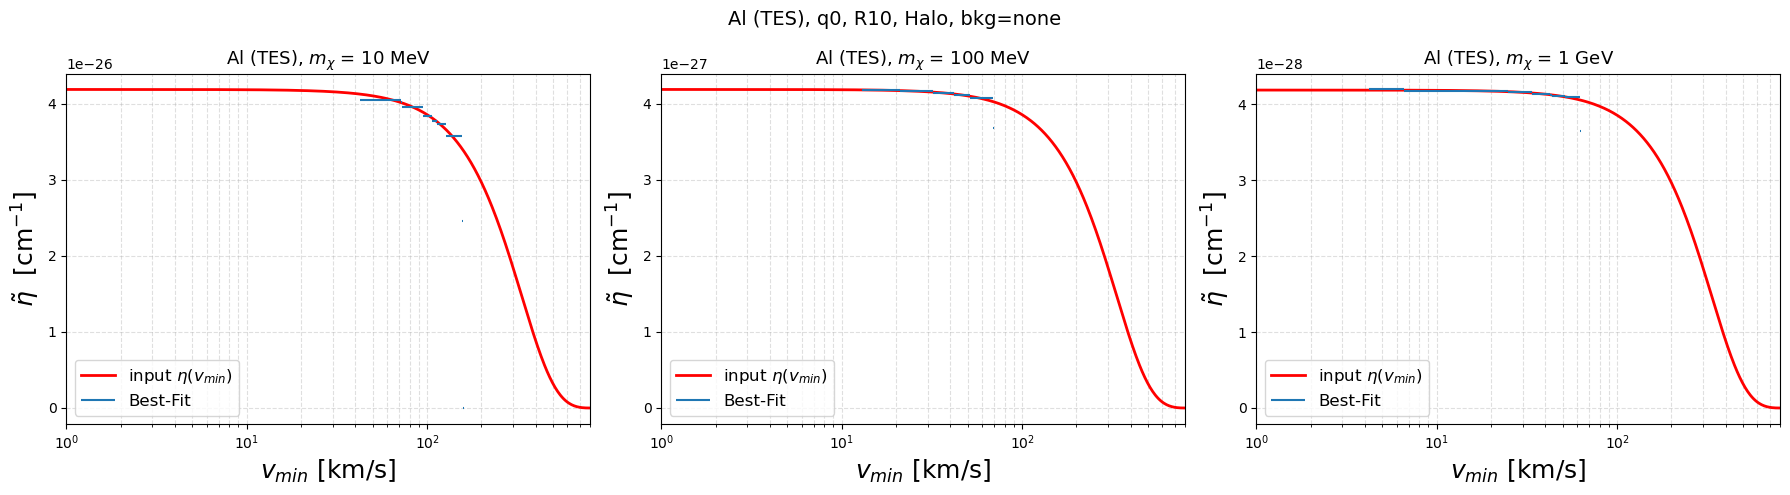

In [43]:
run_masses('Al', q='0', nbins=10, eta='Halo', solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 842.41353634 1361.24603408 1786.34511559 2170.44647043 2508.33218974
 2800.33550215 3055.97526066 3273.30718873 3448.85823151 3633.00292724]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_Halo/flux.pdf
Al q2 M1 R10: 10 E-bins x 884 v_min bins, peak flux 8.08e-31
signal     : [ 78.96117867 128.23855548 170.37322142 208.6017303  242.60438421
 273.39116691 300.22718944 323.76702749 344.80567696 362.82821384]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_Halo/flux.pdf
Al q2 M2 R10: 10 E-bins x 919 v_min bins, peak flux 8.27e-32
signal     : [ 7.81426631 12.74010672 16.92622622 20.73728448 24.13487423 27.21741333
 29.90966794 32.27982262 34.40346422 36.22890084]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qua

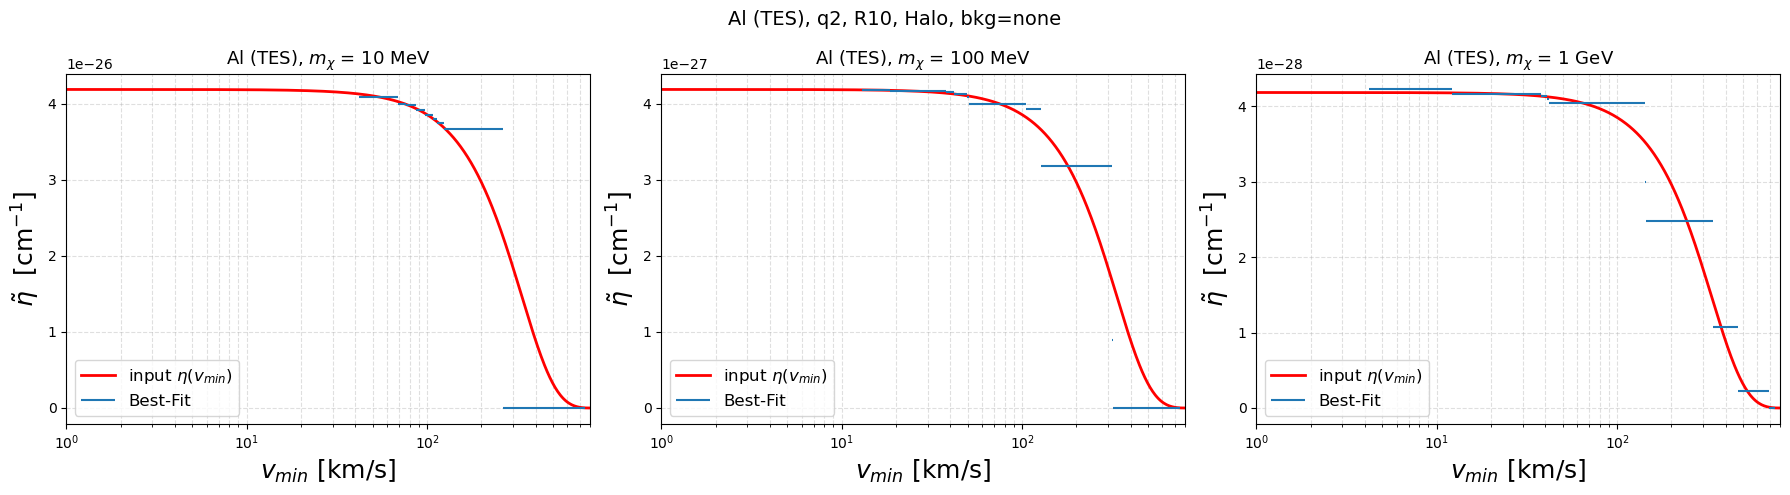

In [44]:
run_masses('Al', q='2', nbins=10, eta='Halo', solver = 'scipy')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [1699.92585467 3308.13037005 4763.77464248 6122.19345466 7359.48626406]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix5/flux.pdf
Al q0 M1 R5: 5 E-bins x 143 v_min bins, peak flux 8.37e-31
signal     : [179.6335762  357.97642131 523.66801658 694.48198423 842.65601716]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix5/flux.pdf
Al q0 M2 R5: 5 E-bins x 68 v_min bins, peak flux 8.96e-32
signal     : [17.18274859 35.15037158 51.57067838 69.00556311 86.01096065]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix5/flux.pdf
Al q0 M3 R5: 5 E-bins x 71 v_min bins, peak flux 9.00e-33


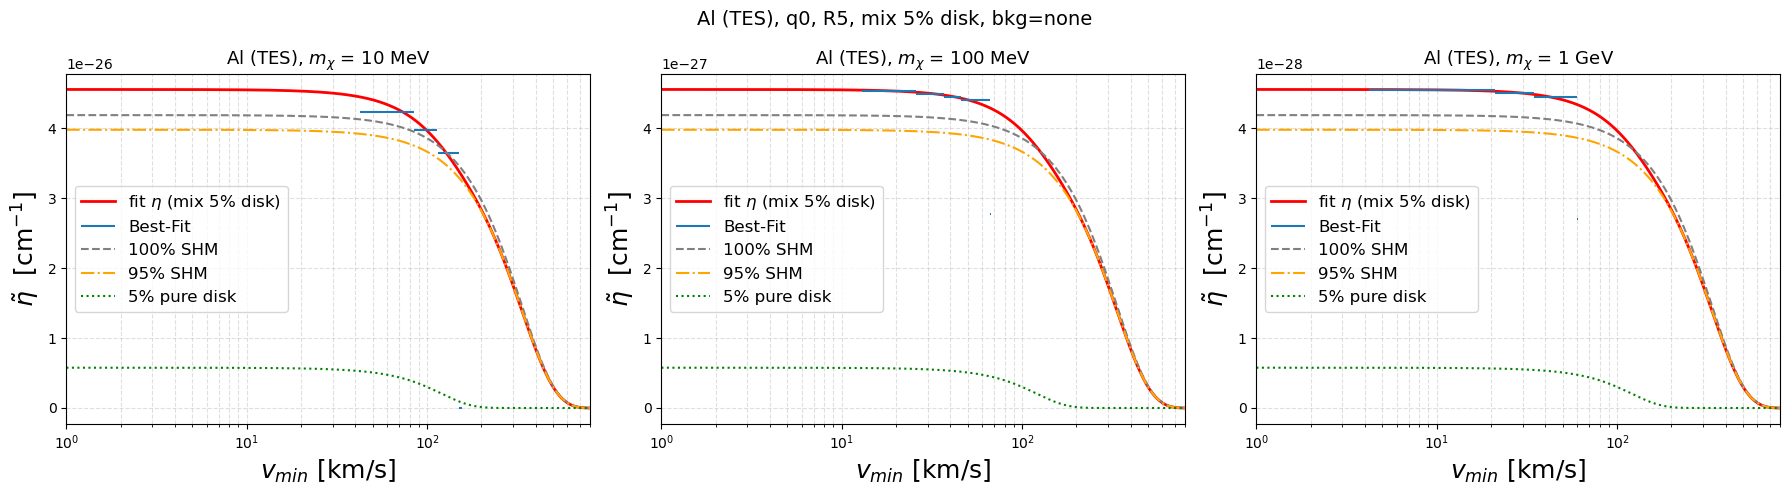

signal     : [1946.47129566 3626.81064402 4969.05131786 6063.41079476 6939.39686827]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix25/flux.pdf
Al q0 M1 R5: 5 E-bins x 143 v_min bins, peak flux 1.01e-30
signal     : [ 236.15051641  467.23285218  677.35261045  888.33660158 1064.21602682]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix25/flux.pdf
Al q0 M2 R5: 5 E-bins x 68 v_min bins, peak flux 1.18e-31
signal     : [ 22.68758724  46.27557333  67.56715959  89.75519736 110.78555307]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix25/flux.pdf
Al q0 M3 R5: 5 E-bins x 71 v_min bins, peak flux 1.19e-32


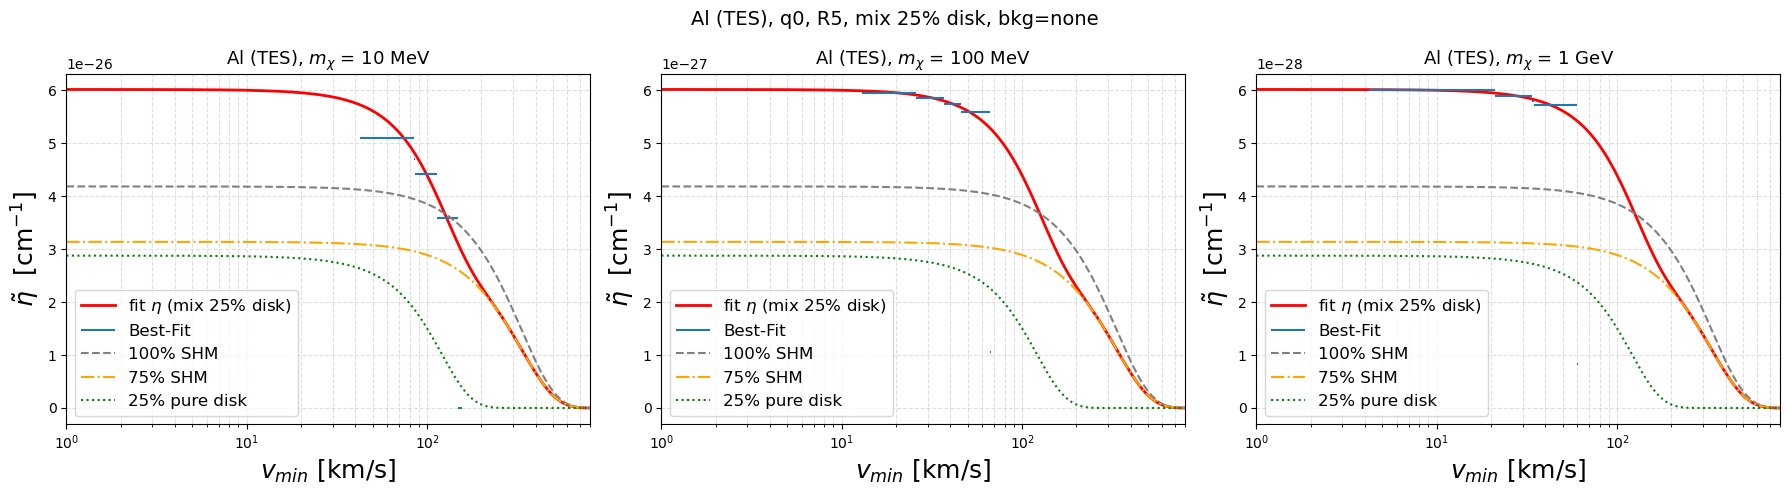

In [45]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=5, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [2197.07516097 3850.50816392 5055.99026117 5930.64547829 6563.20638893]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix5/flux.pdf
Al q2 M1 R5: 5 E-bins x 880 v_min bins, peak flux 8.50e-31
signal     : [210.55232671 379.1537626  507.94269851 606.16633756 679.35860027]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix5/flux.pdf
Al q2 M2 R5: 5 E-bins x 915 v_min bins, peak flux 8.96e-32
signal     : [20.90174045 37.74549724 50.67000994 60.58493508 68.0267693 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix5/flux.pdf
Al q2 M3 R5: 5 E-bins x 926 v_min bins, peak flux 8.97e-33


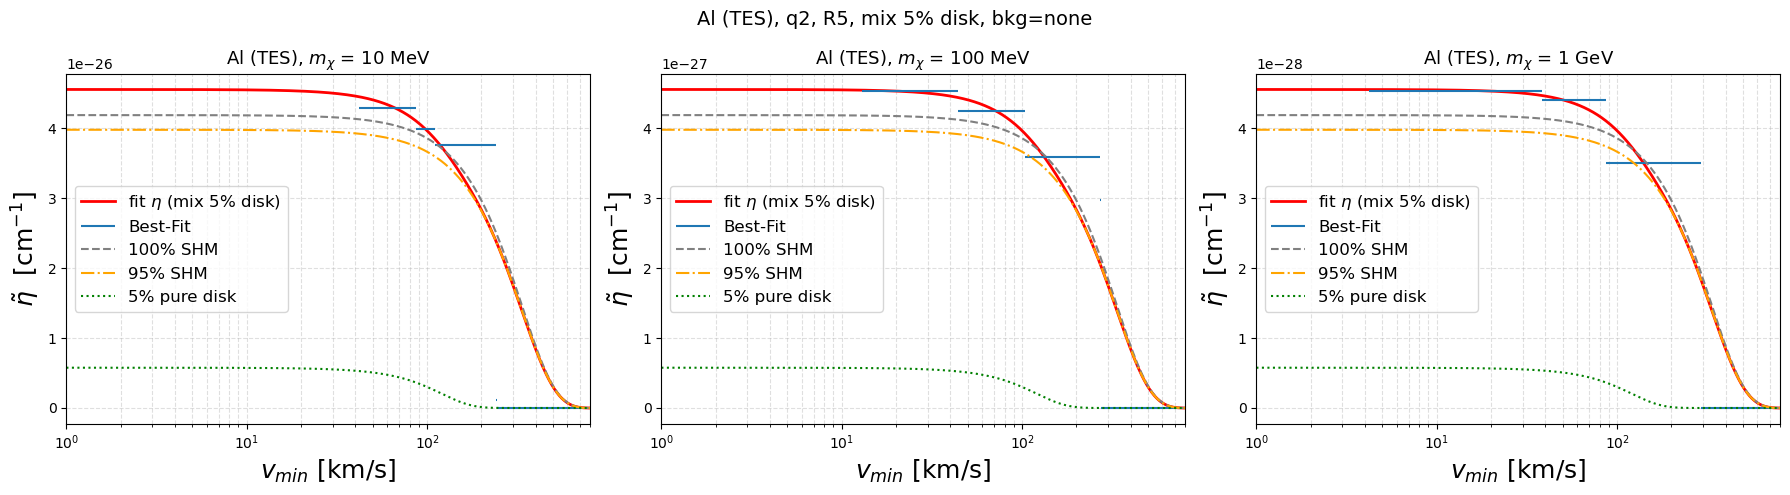

signal     : [2574.98570136 4138.20444943 5011.58693232 5501.14367736 5788.47549748]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix25/flux.pdf
Al q2 M1 R5: 5 E-bins x 880 v_min bins, peak flux 1.05e-30
signal     : [262.35957095 448.39429906 570.06839897 648.1858768  695.50642164]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix25/flux.pdf
Al q2 M2 R5: 5 E-bins x 915 v_min bins, peak flux 1.18e-31
signal     : [26.11898857 44.88426851 57.32931038 65.46160245 70.50511992]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix25/flux.pdf
Al q2 M3 R5: 5 E-bins x 926 v_min bins, peak flux 1.18e-32


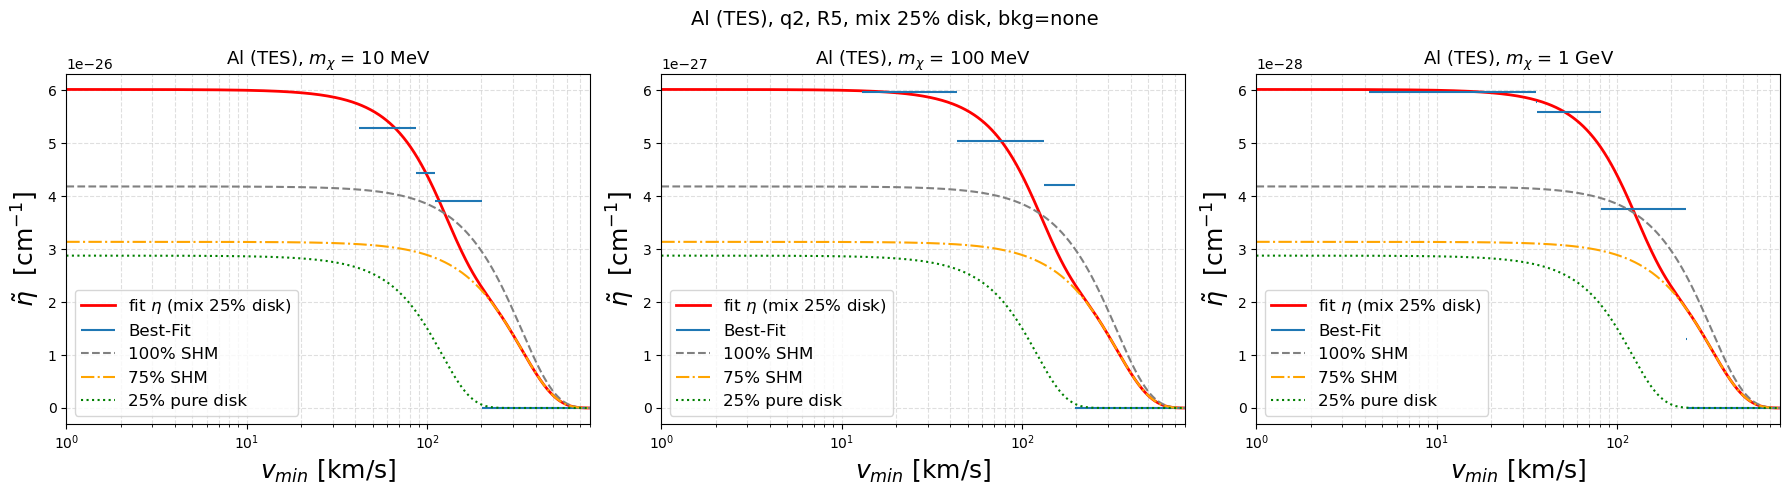

In [46]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 10 energy bins

signal     : [ 665.23849069 1118.29046113 1530.67452495 1931.95926554 2315.53718848
 2684.65339232 3032.15791786 3372.60302171 3703.56946885 4023.21982978]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix5/flux.pdf
Al q0 M1 R10: 10 E-bins x 147 v_min bins, peak flux 8.52e-31
signal     : [ 74.42719656 116.59307394 160.15445413 209.01871214 251.34786888
 291.26109034 339.2927999  377.12254461 421.25356154 460.23348104]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix5/flux.pdf
Al q0 M2 R10: 10 E-bins x 71 v_min bins, peak flux 8.98e-32
signal     : [ 6.74729645 11.52543271 15.83967908 20.90412857 25.05306866 29.19298182
 34.10333445 38.13379117 42.17040703 46.95624489]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

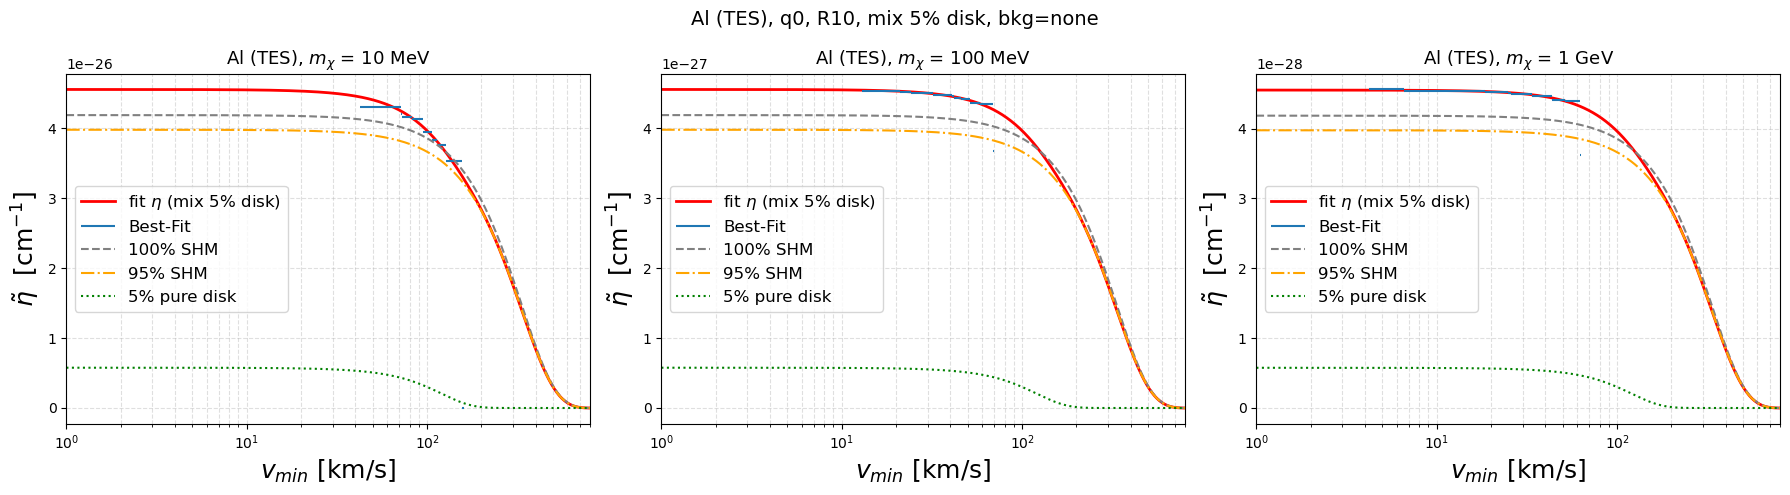

signal     : [ 771.52864301 1270.84702936 1701.10396476 2095.41920603 2449.31881982
 2765.82659816 3044.09840616 3299.22013027 3534.12265088 3750.03990249]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix25/flux.pdf
Al q0 M1 R10: 10 E-bins x 147 v_min bins, peak flux 1.06e-30
signal     : [ 98.00537299 153.08491424 209.52562607 272.28321611 325.94547134
 375.86302331 435.34844922 481.0833065  533.8381424  579.19817704]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix25/flux.pdf
Al q0 M2 R10: 10 E-bins x 71 v_min bins, peak flux 1.18e-31
signal     : [ 8.91324967 15.21014101 20.87400186 27.49105575 32.86872551 38.18968311
 44.44531692 49.49889479 54.48761352 60.32313456]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qu

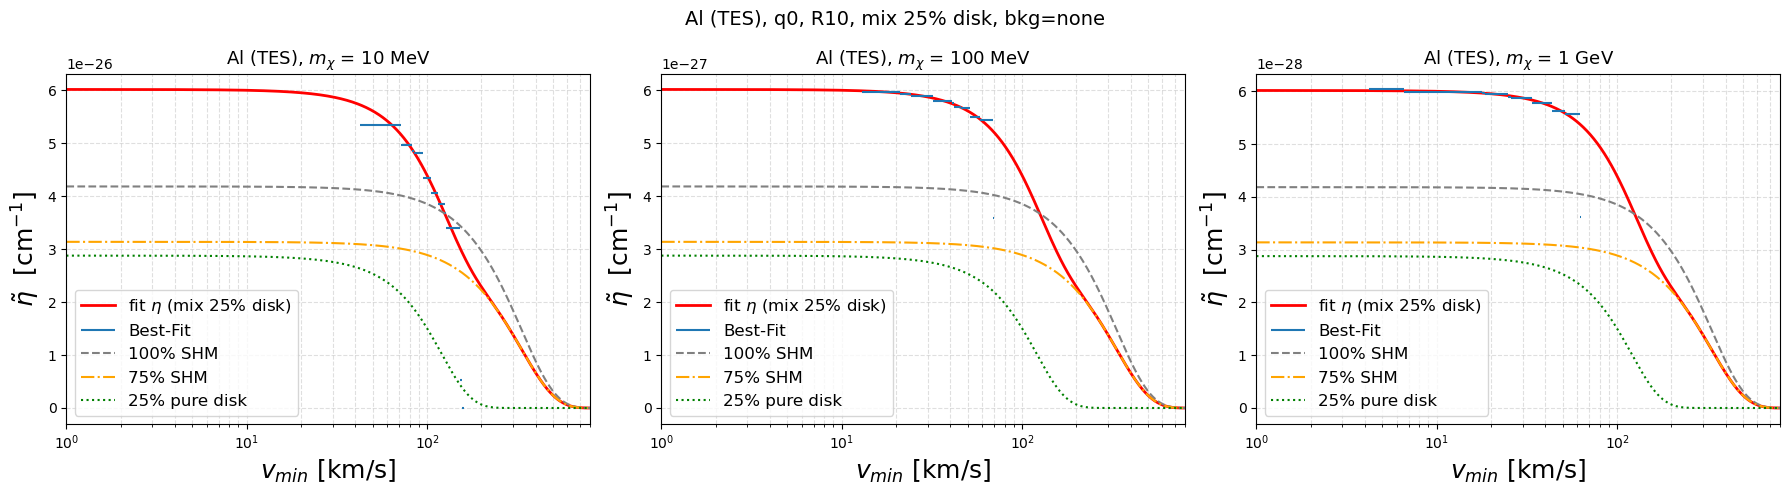

In [47]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=10, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 887.78050288 1415.11480532 1832.48123034 2199.71694549 2515.17642427
 2781.85130652 3011.96555727 3204.84321182 3357.64511868 3521.21873354]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix5/flux.pdf
Al q2 M1 R10: 10 E-bins x 884 v_min bins, peak flux 8.64e-31
signal     : [ 84.60402292 136.19227954 179.35695425 217.75726956 251.24327486
 281.03233694 306.51759987 328.48330704 347.81022133 364.05384588]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix5/flux.pdf
Al q2 M2 R10: 10 E-bins x 919 v_min bins, peak flux 8.98e-32
signal     : [ 8.37840288 13.54555005 17.84562237 21.68801723 25.04939603 28.04792433
 30.62007082 32.84680025 34.81175953 36.46986136]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qua

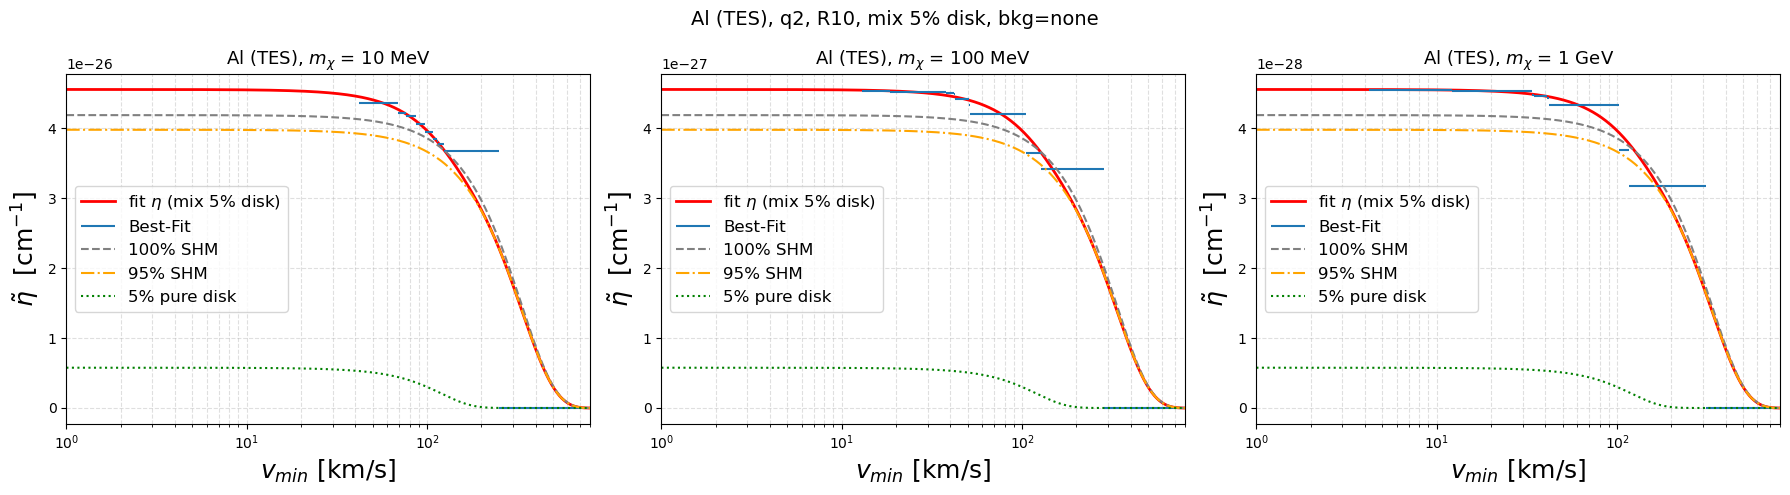

signal     : [1069.24836902 1630.58989028 2017.02568934 2316.79884572 2542.55336237
 2707.91452401 2835.92674369 2930.98730416 2992.79266739 3074.08195873]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix25/flux.pdf
Al q2 M1 R10: 10 E-bins x 884 v_min bins, peak flux 1.09e-30
signal     : [107.1753999  168.00717579 215.29188558 254.37942663 285.79883743
 311.59701707 331.67924159 347.34842525 359.8283988  368.95637403]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix25/flux.pdf
Al q2 M2 R10: 10 E-bins x 919 v_min bins, peak flux 1.18e-31
signal     : [10.63494918 16.76732337 21.52320698 25.49094823 28.70748324 31.36996831
 33.46168232 35.11471077 36.4449408  37.43370344]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Q

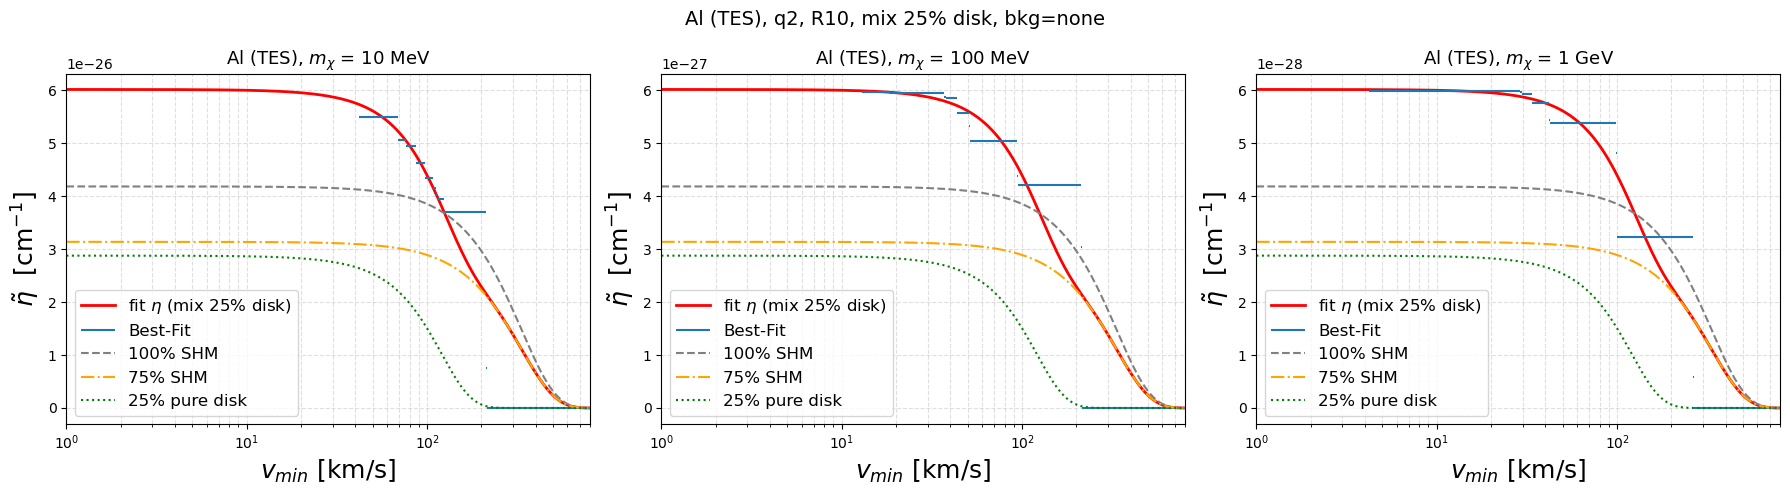

In [48]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=10, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [2.36412745e+14 2.38842861e+11 1.43354698e+08 2.07127155e+04
 7.98173126e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Bound/flux.pdf
Al q0 M3 R5: 5 E-bins x 71 v_min bins, peak flux 6.30e-19


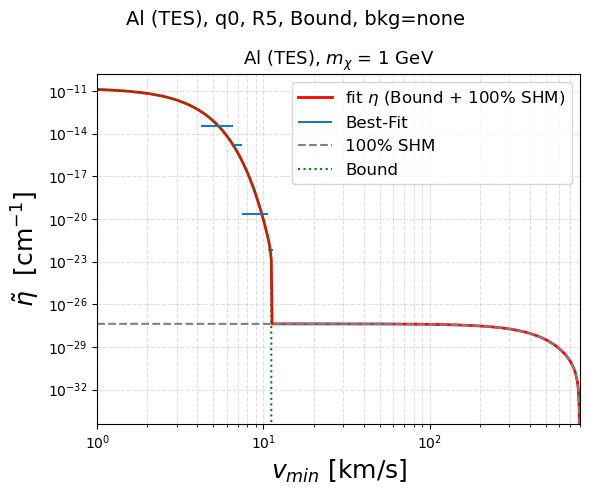

In [49]:
run_masses('Al', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [2.01745002e+12 1.80023149e+08 6.40535619e+04 6.26910805e+01
 6.74071816e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Bound/flux.pdf
Al q2 M3 R5: 5 E-bins x 926 v_min bins, peak flux 2.40e-19


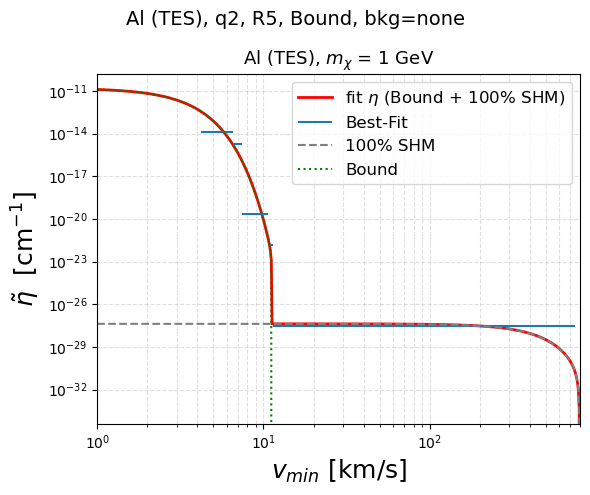

In [50]:
run_masses('Al', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 10 energy bins

signal     : [2.28806892e+14 9.73575431e+12 2.34242992e+11 6.25499600e+09
 1.41881742e+08 2.50623320e+06 2.06804152e+04 3.52925153e+01
 3.90911054e+01 4.36145225e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10_Bound/flux.pdf
Al q0 M3 R10: 10 E-bins x 74 v_min bins, peak flux 1.39e-18


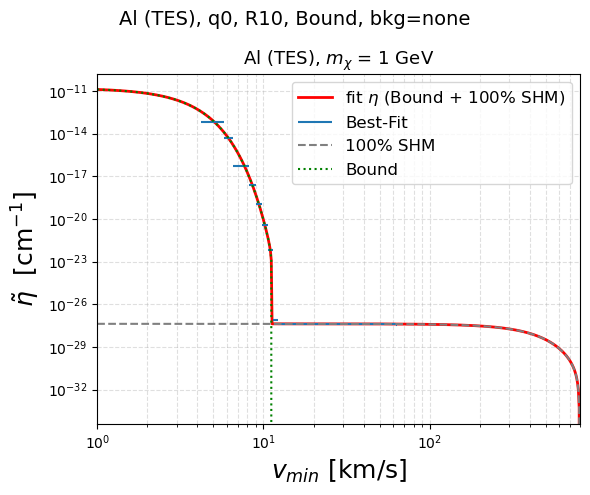

In [51]:
run_masses('Al', q='0', nbins=10, eta='Bound', masses=('3',))

### Light mediator (q2), 10 energy bins

signal     : [2.00747570e+12 1.37129880e+10 1.78148206e+08 2.70658148e+06
 6.37455429e+04 6.37839343e+02 3.32349802e+01 3.22798226e+01
 3.44034642e+01 3.62289008e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R10_Bound/flux.pdf
Al q2 M3 R10: 10 E-bins x 930 v_min bins, peak flux 1.05e-18


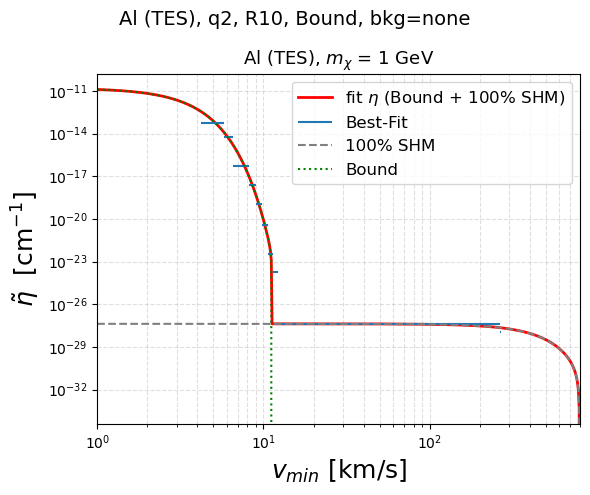

In [52]:
run_masses('Al', q='2', nbins=10, eta='Bound', masses=('3',))

## With a background scenario (Halo)

signal     : [1638.28949442 3228.46030156 4712.45547363 6136.88911964 7464.50861301]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M1 R5: 5 E-bins x 143 v_min bins, peak flux 7.94e-31
signal     : [165.50434115 330.66231359 485.24686812 646.01832989 787.26601474]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M2 R5: 5 E-bins x 68 v_min bins, peak flux 8.26e-32
signal     : [15.80653893 32.36907114 47.57155808 63.81815455 79.81731255]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M3 R5: 5 E-bins x 71 v_min bins, peak flux 8.30e-33


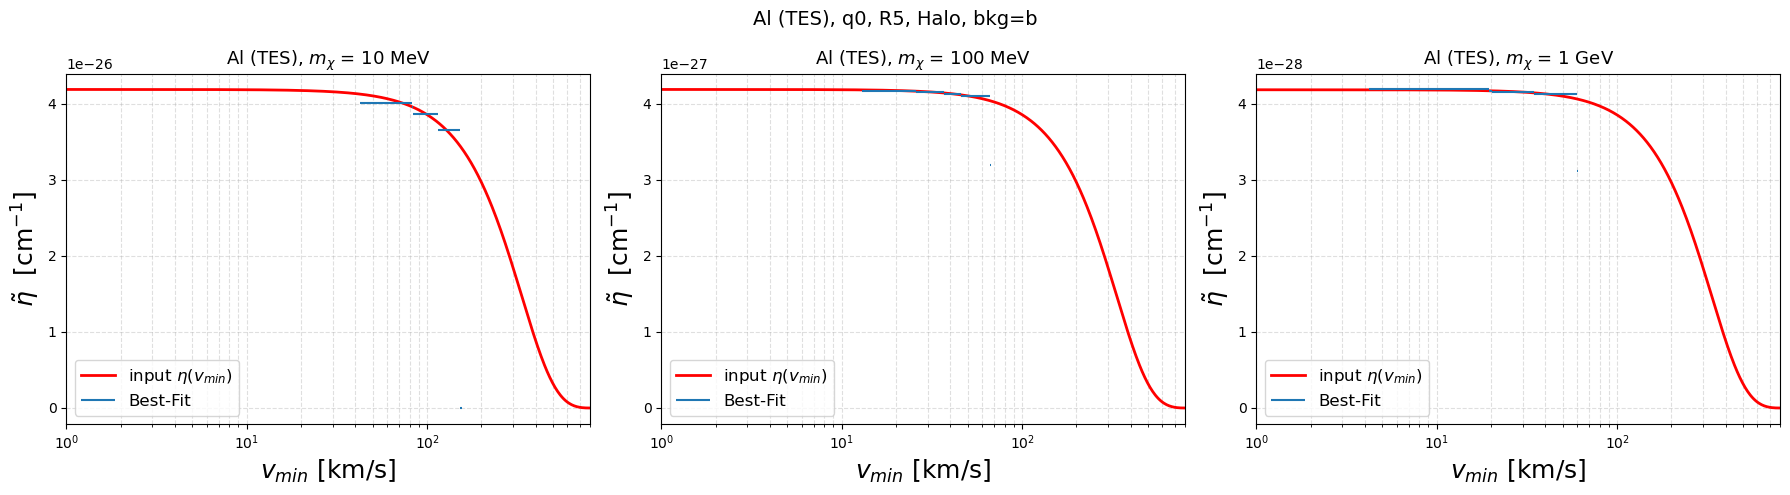

In [53]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='b', solver = 'scipy', save = False)

signal     : [2102.59752587 3778.58409254 5067.09109339 6038.02092852 6756.88911179]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M1 R5: 5 E-bins x 880 v_min bins, peak flux 8.00e-31
signal     : [197.60051565 361.84362849 492.41127339 595.66145275 675.32164492]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M2 R5: 5 E-bins x 915 v_min bins, peak flux 8.25e-32
signal     : [19.59742842 35.96080442 49.00518483 59.36576824 67.40718164]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M3 R5: 5 E-bins x 926 v_min bins, peak flux 8.26e-33


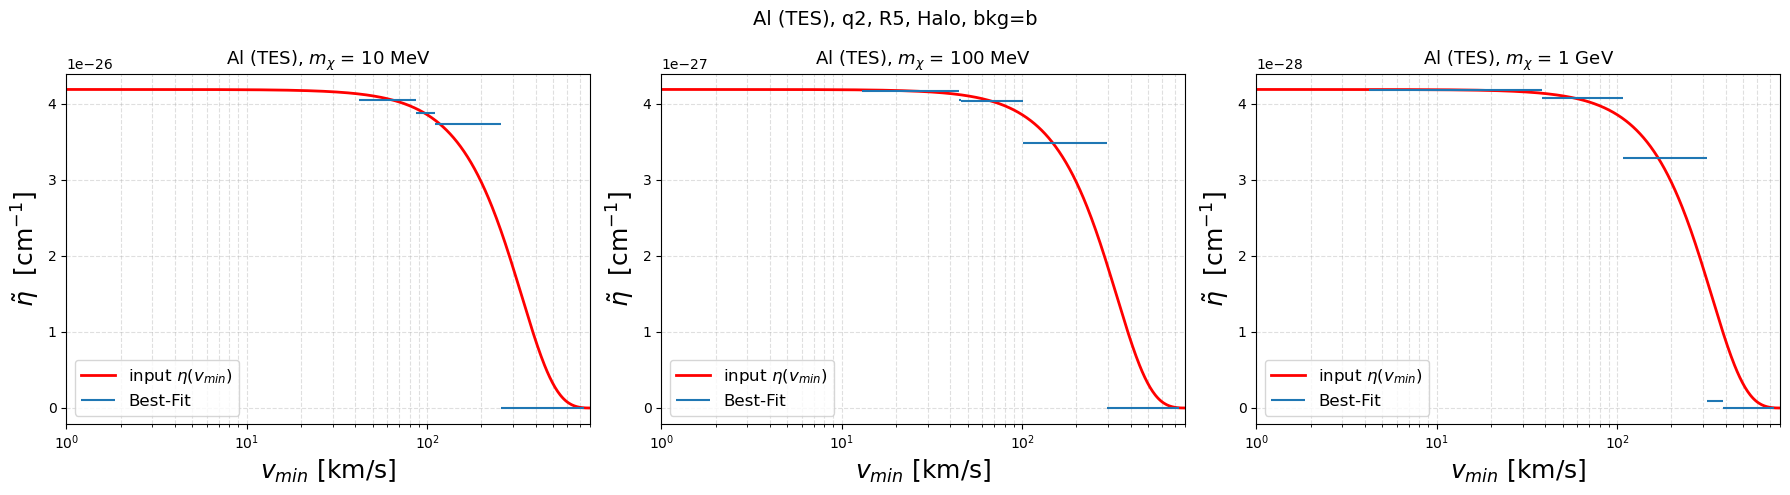

In [54]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='b', save = False)

signal     : [1638.28949442 3228.46030156 4712.45547363 6136.88911964 7464.50861301]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M1 R5: 5 E-bins x 143 v_min bins, peak flux 7.94e-31
signal     : [165.50434115 330.66231359 485.24686812 646.01832989 787.26601474]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M2 R5: 5 E-bins x 68 v_min bins, peak flux 8.26e-32
signal     : [15.80653893 32.36907114 47.57155808 63.81815455 79.81731255]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M3 R5: 5 E-bins x 71 v_min bins, peak flux 8.29e-33


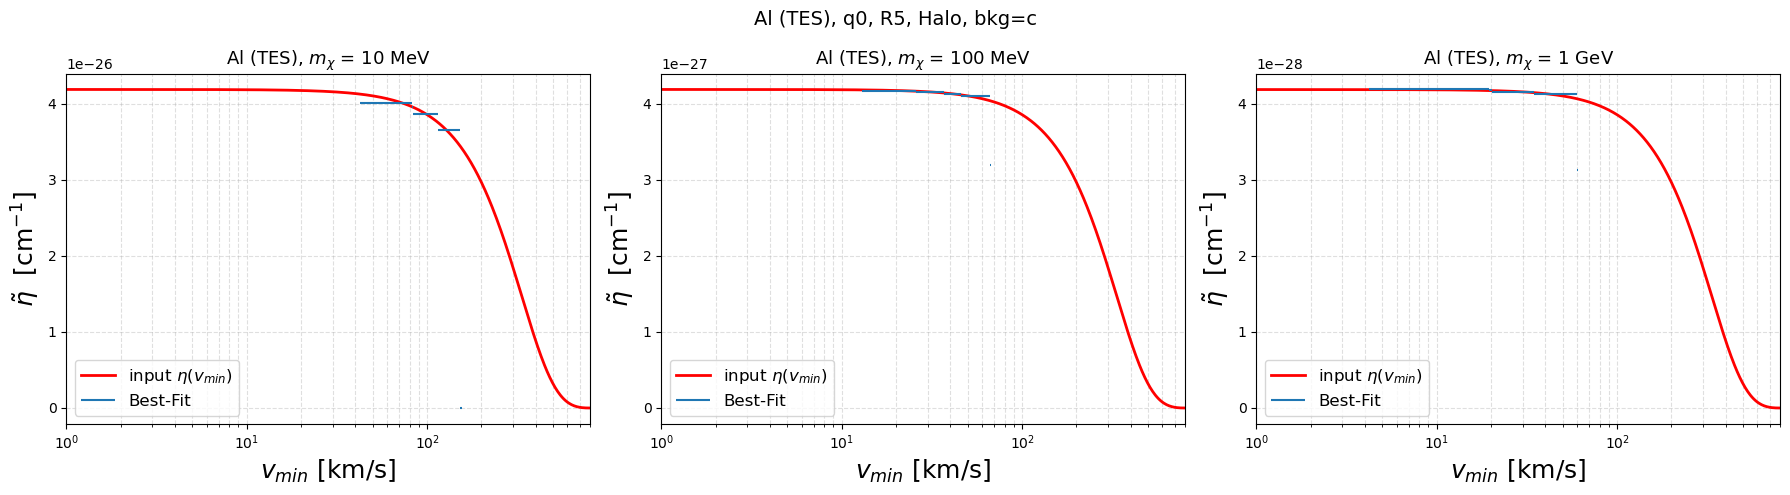

In [55]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='c', solver = 'scipy', save = False)

signal     : [2102.59752587 3778.58409254 5067.09109339 6038.02092852 6756.88911179]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M1 R5: 5 E-bins x 880 v_min bins, peak flux 8.00e-31
signal     : [197.60051565 361.84362849 492.41127339 595.66145275 675.32164492]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M2 R5: 5 E-bins x 915 v_min bins, peak flux 8.25e-32
signal     : [19.59742842 35.96080442 49.00518483 59.36576824 67.40718164]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M3 R5: 5 E-bins x 926 v_min bins, peak flux 8.26e-33


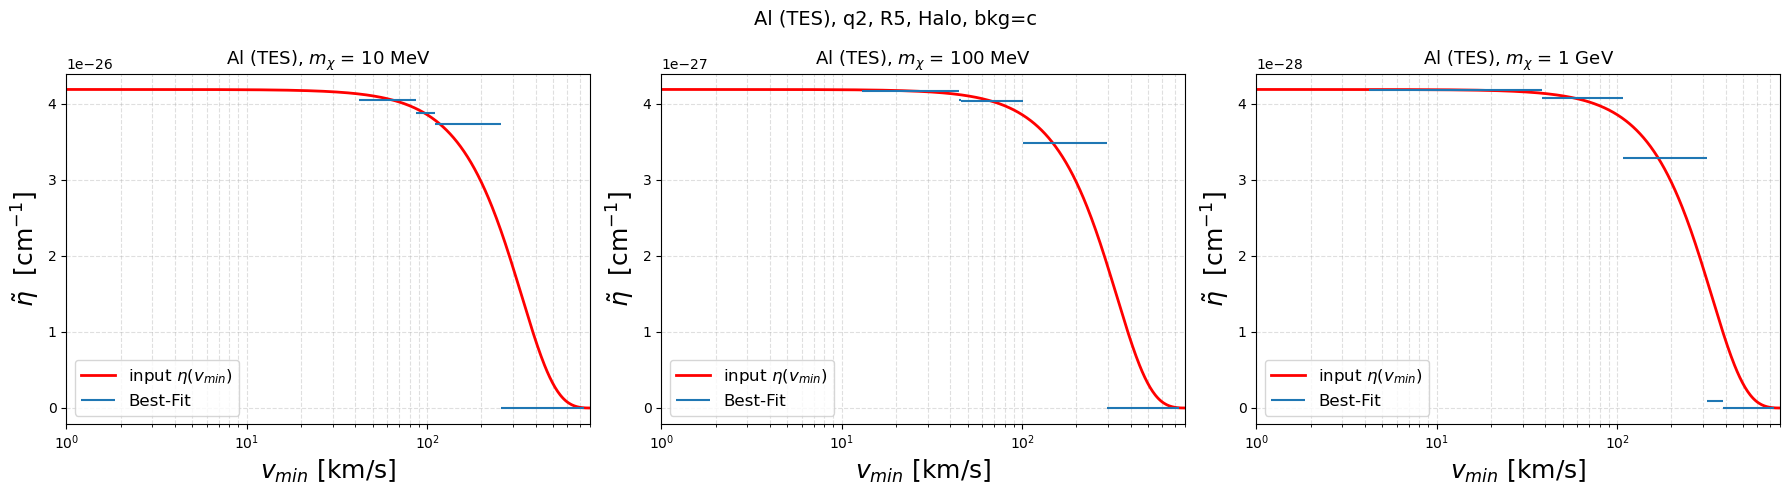

In [56]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='c', save = False)

# MKID (TiN)

Titanium-nitride detector, Lindhard dielectric. Threshold **0.2 eV** (bins start at 0.2 eV, fine binning **`R9`**). Heavy mediator (`q0`) only so far.

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [1359.12322283 4052.30786304 5883.51513684 7554.01358827 9026.36872217]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_Halo/flux.pdf
TiN q0 M1 R5: 5 E-bins x 259 v_min bins, peak flux 7.95e-31
signal     : [129.30051745 390.48689403 574.878499   747.38469365 905.2764834 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_Halo/flux.pdf
TiN q0 M2 R5: 5 E-bins x 286 v_min bins, peak flux 8.28e-32
signal     : [12.83692324 38.80960905 57.19799193 74.47940973 90.33351323]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Halo/flux.pdf
TiN q0 M3 R5: 5 E-bins x 298 v_min bins, peak flux 8.28e-33


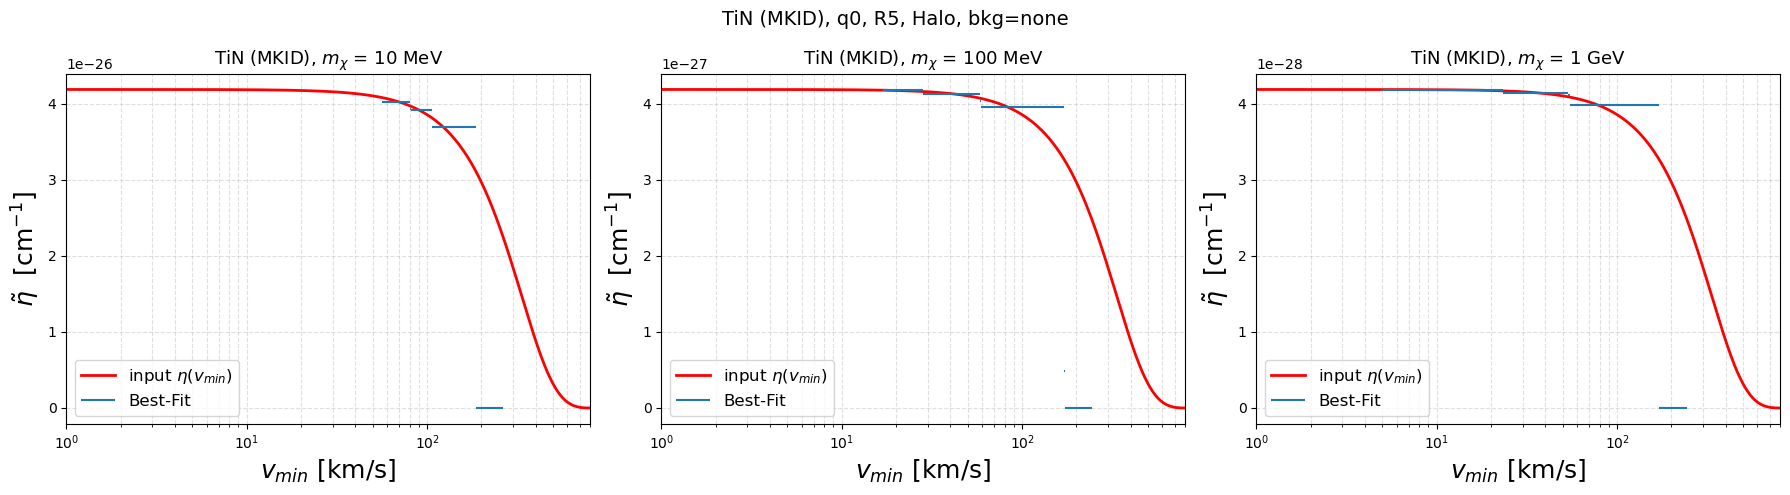

In [57]:
run_masses('TiN', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [ 9953.25801116 26122.46272848 32845.01184601 36934.80746344
 39145.50446729]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_Halo/flux.pdf
TiN q2 M1 R5: 5 E-bins x 892 v_min bins, peak flux 8.04e-31
signal     : [ 931.50735882 2473.74112357 3158.36946523 3614.39108647 3894.05553476]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_Halo/flux.pdf
TiN q2 M2 R5: 5 E-bins x 940 v_min bins, peak flux 8.33e-32
signal     : [ 92.46668727 245.82730068 314.31866436 360.24421877 388.72160874]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Halo/flux.pdf
TiN q2 M3 R5: 5 E-bins x 955 v_min bins, peak flux 8.34e-33


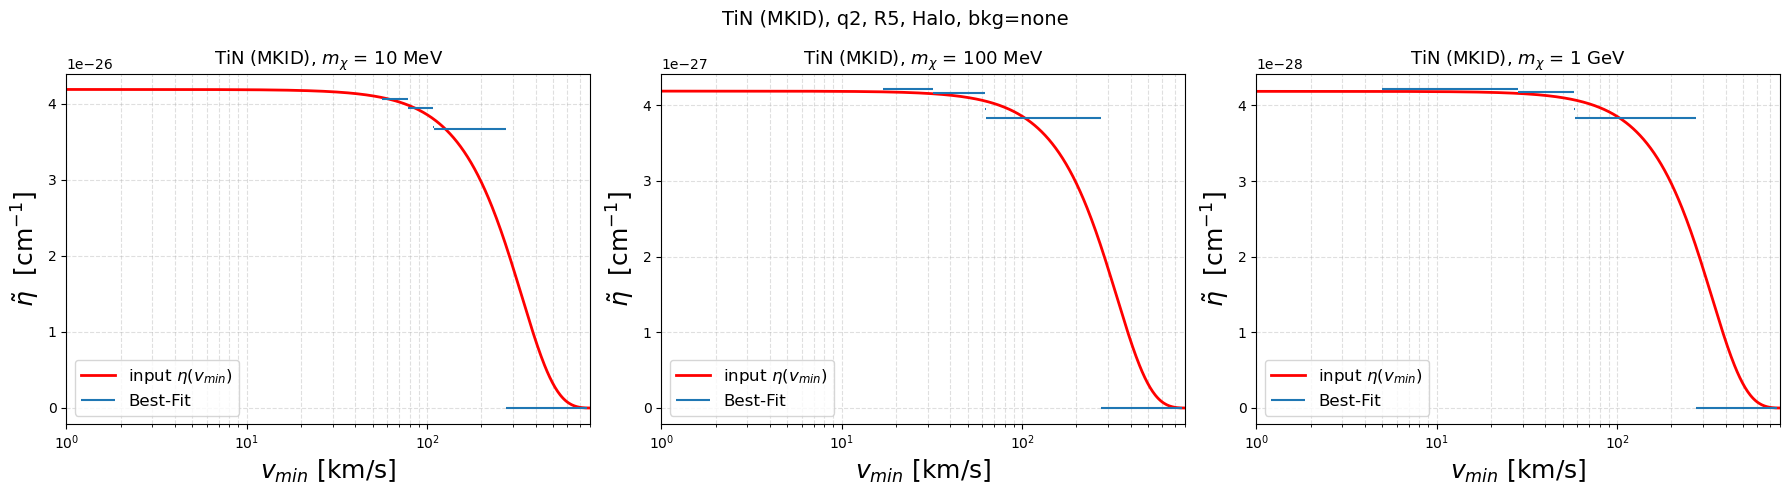

In [58]:
run_masses('TiN', q='2', nbins=5, eta='Halo')

### Heavy mediator (q0), 9 energy bins

signal     : [1359.12322283 1874.33921638 2369.61545543 2860.30679677 3302.35928426
 3748.41603483 4167.53287899 4549.19917267 4907.18819442]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_Halo/flux.pdf
TiN q0 M1 R9: 9 E-bins x 272 v_min bins, peak flux 7.96e-31
signal     : [129.30051745 179.75676516 229.32893447 277.62889001 324.50355898
 369.73722951 413.26077154 454.61105607 493.70375858]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_Halo/flux.pdf
TiN q0 M2 R9: 9 E-bins x 298 v_min bins, peak flux 8.25e-32
signal     : [12.83692324 17.85193543 22.79842326 27.61829623 32.30320746 36.831712
 41.19633962 45.34587979 49.28636024]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/

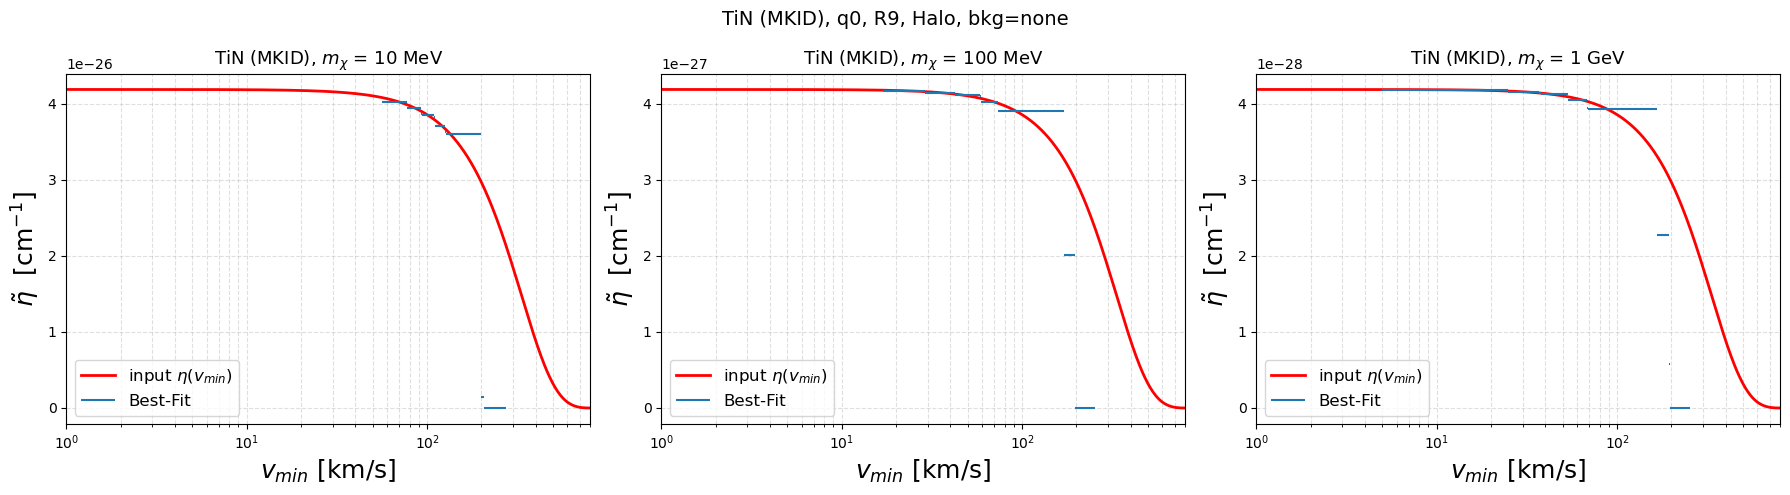

In [59]:
run_masses('TiN', q='0', nbins=9, eta='Halo')

### Light mediator (q2), 9 energy bins

signal     : [ 9953.25801116 12606.59459246 14759.31463596 16538.56956824
 17873.95117908 18952.23439002 19752.3792691  20325.27697472
 20685.78102323]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_Halo/flux.pdf
TiN q2 M1 R9: 9 E-bins x 893 v_min bins, peak flux 8.03e-31
signal     : [ 931.50735882 1188.30233857 1403.50728217 1581.39883326 1727.5793802
 1846.03454349 1940.64509513 2013.09737312 2066.53567585]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_Halo/flux.pdf
TiN q2 M2 R9: 9 E-bins x 941 v_min bins, peak flux 8.30e-32
signal     : [ 92.46668727 118.04075642 139.5190144  157.31817935 171.98854831
 183.92054258 193.49527962 200.8756753  206.37088609]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_an

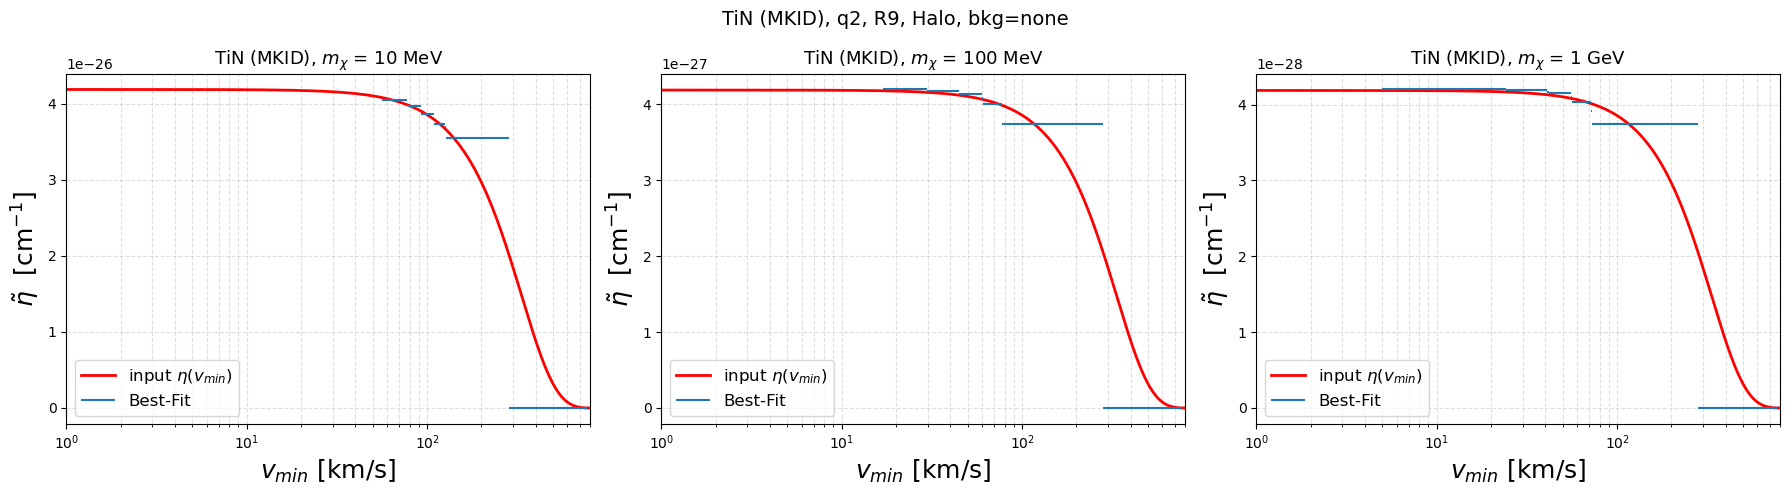

In [66]:
run_masses('TiN', q='2', nbins=9, eta='Halo')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [1434.32604619 4213.32931204 5991.3213958  7538.80206597 8858.32161184]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix5/flux.pdf
TiN q0 M1 R5: 5 E-bins x 259 v_min bins, peak flux 8.38e-31
signal     : [139.96355306 419.84652705 610.2981197  780.56815582 928.63463679]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix5/flux.pdf
TiN q0 M2 R5: 5 E-bins x 286 v_min bins, peak flux 8.95e-32
signal     : [13.91168917 41.80795036 60.9015996  78.08303807 93.06885309]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix5/flux.pdf
TiN q0 M3 R5: 5 E-bins x 298 v_min bins, peak flux 8.97e-33


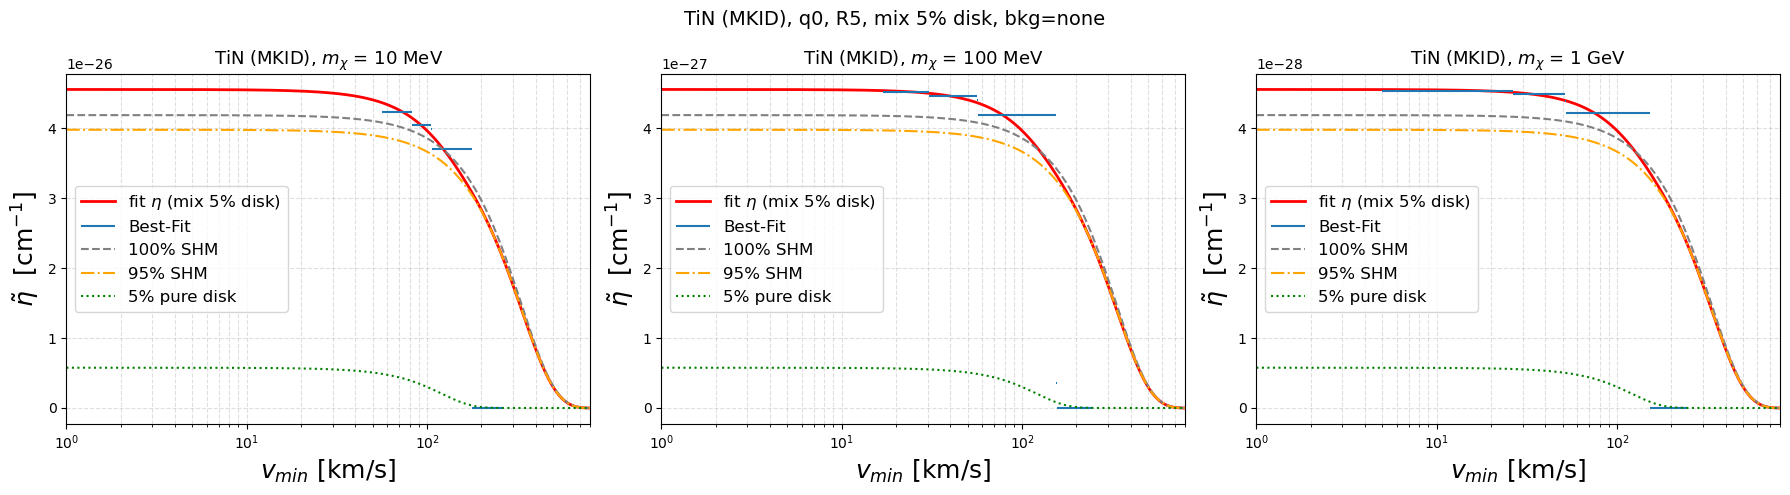

signal     : [1735.13733962 4857.41510805 6422.54643163 7477.95597677 8186.13317051]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix25/flux.pdf
TiN q0 M1 R5: 5 E-bins x 259 v_min bins, peak flux 1.02e-30
signal     : [ 182.6156955   537.28505913  751.97660248  913.30200453 1022.06725032]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix25/flux.pdf
TiN q0 M2 R5: 5 E-bins x 286 v_min bins, peak flux 1.17e-31
signal     : [ 18.21075288  53.8013156   75.71603028  92.49755143 104.01021252]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix25/flux.pdf
TiN q0 M3 R5: 5 E-bins x 298 v_min bins, peak flux 1.18e-32


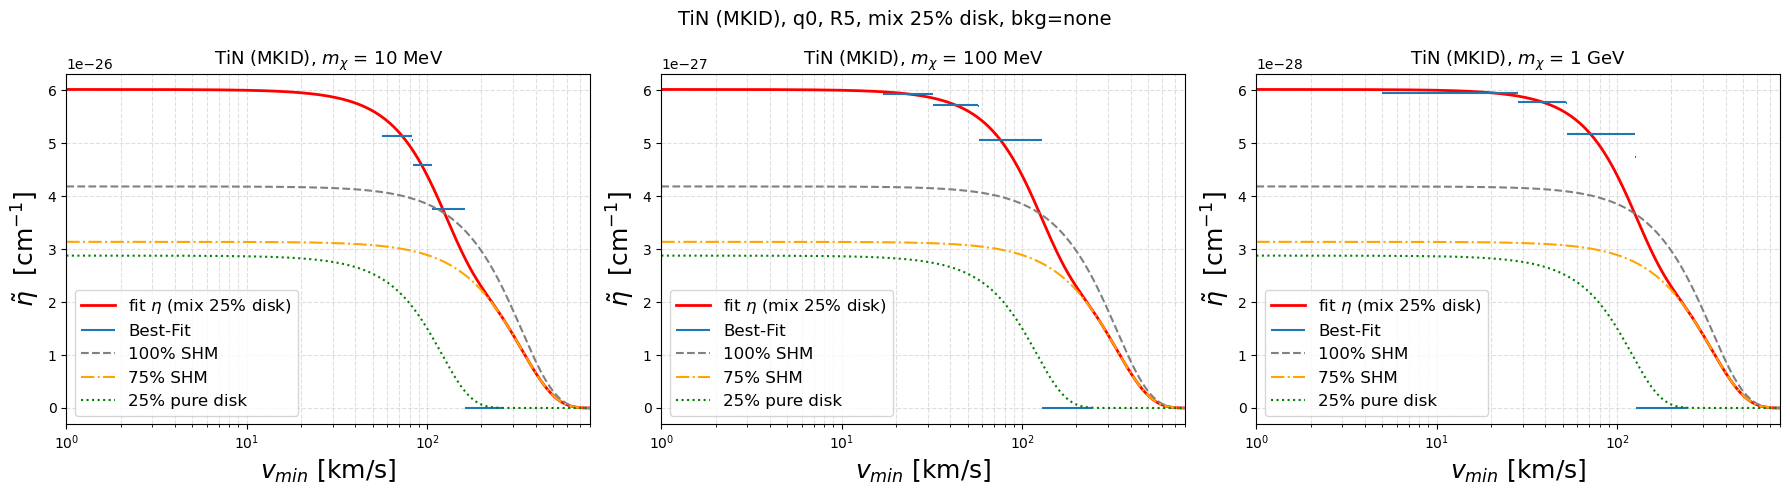

In [60]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=5, disk_fraction=p)

### Light mediator (q2), 5 energy bins

signal     : [10261.92393529 26386.2566459  32486.41796672 35983.75405314
 37754.98577233]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix5/flux.pdf
TiN q2 M1 R5: 5 E-bins x 892 v_min bins, peak flux 8.52e-31
signal     : [ 974.41450675 2547.85797409 3195.81070389 3602.57261841 3833.35347975]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix5/flux.pdf
TiN q2 M2 R5: 5 E-bins x 940 v_min bins, peak flux 9.04e-32
signal     : [ 96.82293653 253.5739542  318.67509736 359.86735264 383.52765452]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix5/flux.pdf
TiN q2 M3 R5: 5 E-bins x 955 v_min bins, peak flux 9.05e-33


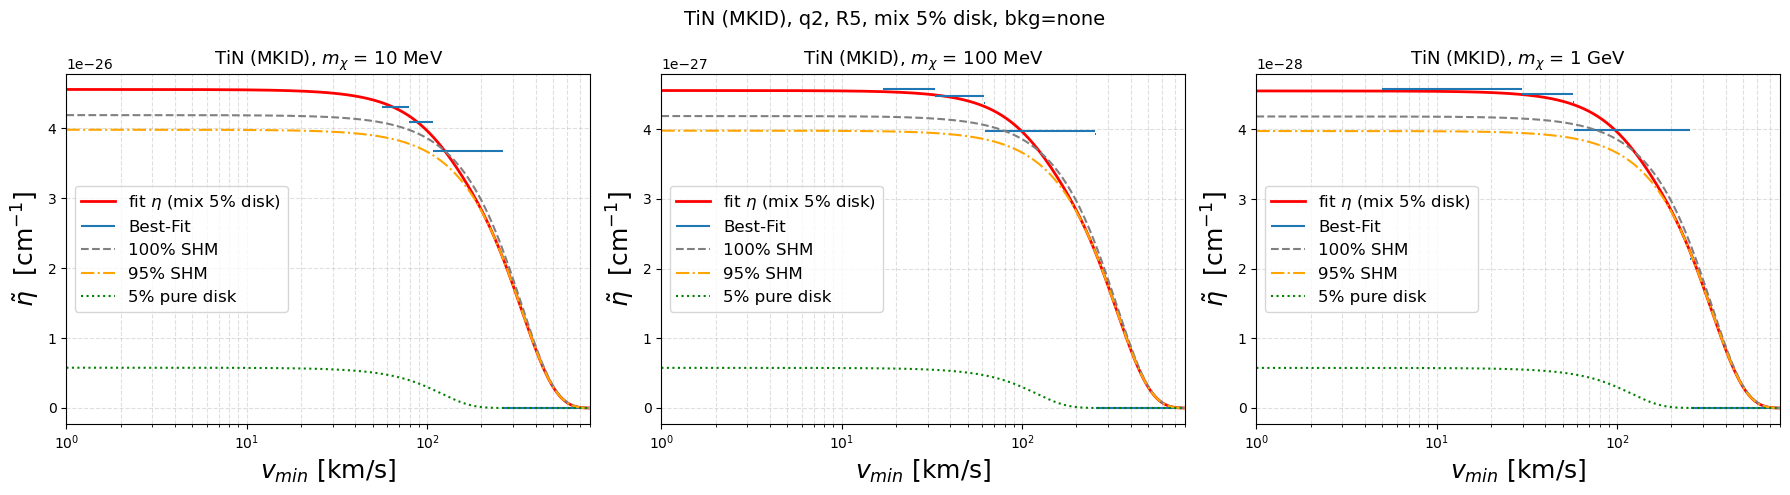

signal     : [11496.58763183 27441.43231559 31052.04244957 32179.54041194
 32192.91099249]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix25/flux.pdf
TiN q2 M1 R5: 5 E-bins x 892 v_min bins, peak flux 1.04e-30
signal     : [1146.0430985  2844.32537619 3345.57565853 3555.29874617 3590.54525968]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix25/flux.pdf
TiN q2 M2 R5: 5 E-bins x 940 v_min bins, peak flux 1.18e-31
signal     : [114.24793358 284.5605683  336.10082939 358.35988812 362.75183765]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix25/flux.pdf
TiN q2 M3 R5: 5 E-bins x 955 v_min bins, peak flux 1.19e-32


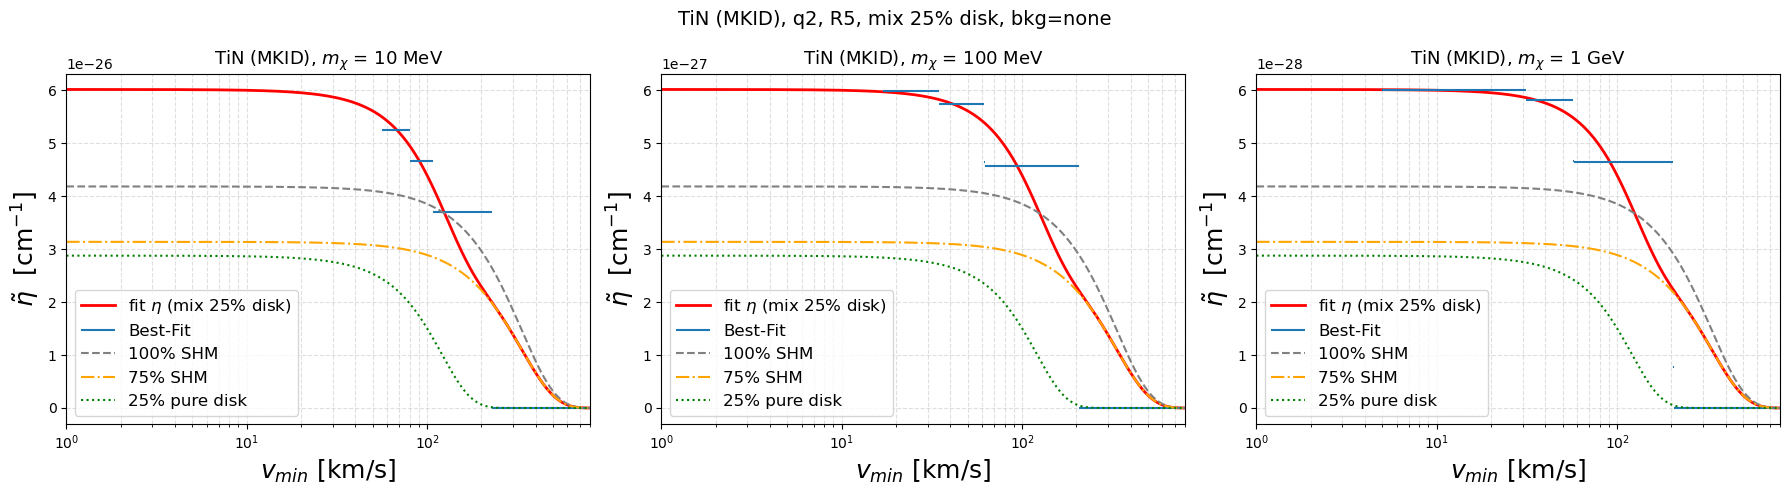

In [61]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 9 energy bins

signal     : [1434.32604619 1959.93158122 2452.76785449 2929.50201873 3346.19452158
 3759.49433656 4140.57054739 4481.58229853 4798.75837189]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix5/flux.pdf
TiN q0 M1 R9: 9 E-bins x 272 v_min bins, peak flux 8.41e-31
signal     : [139.96355306 193.82990655 246.01242959 295.92685692 343.320427
 387.95501756 429.81796198 468.55354222 504.24604963]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix5/flux.pdf
TiN q0 M2 R9: 9 E-bins x 298 v_min bins, peak flux 8.95e-32
signal     : [13.91168917 19.28139223 24.50960728 29.51721751 34.28475113 38.78642368
 43.0179988  46.93666566 50.56246662]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/

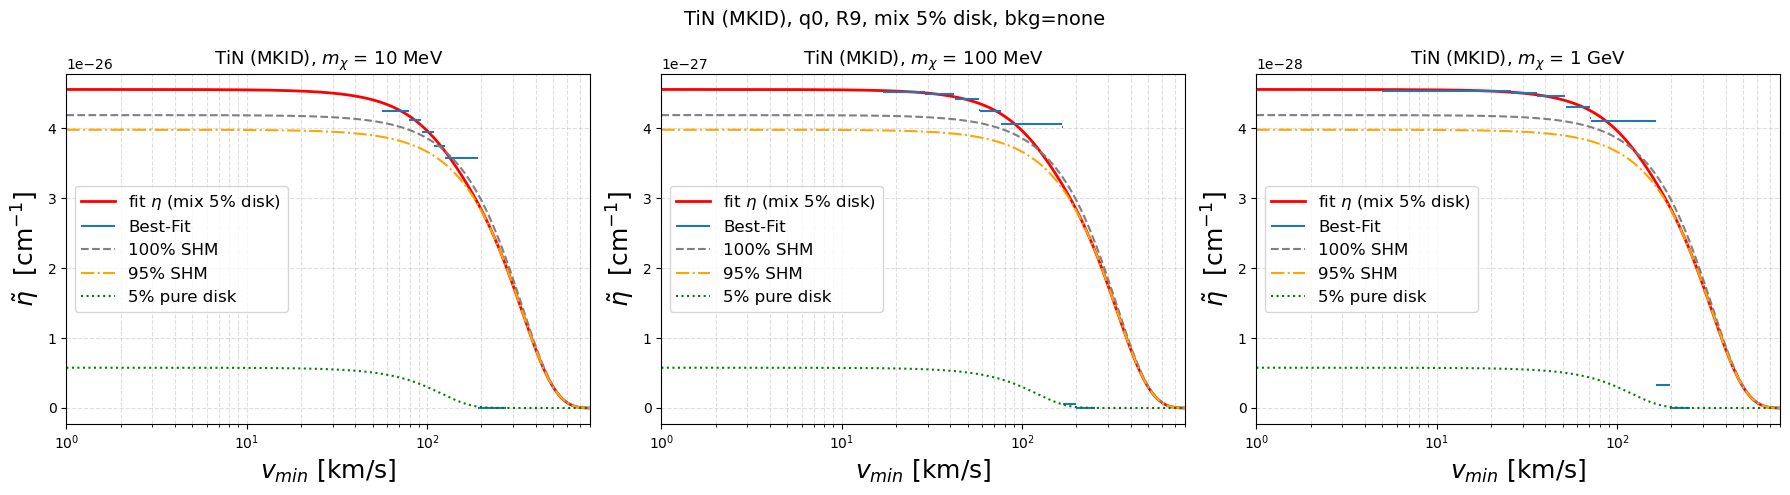

signal     : [1735.13733962 2302.30104056 2785.37745075 3206.28290657 3521.53547089
 3803.80754349 4032.72122103 4211.11480198 4365.03908179]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix25/flux.pdf
TiN q0 M1 R9: 9 E-bins x 272 v_min bins, peak flux 1.02e-30
signal     : [182.6156955  250.12247211 312.7464101  369.11872453 418.58789907
 460.82616974 496.04672376 524.32348685 546.41521384]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix25/flux.pdf
TiN q0 M2 R9: 9 E-bins x 298 v_min bins, peak flux 1.17e-31
signal     : [18.21075288 24.99921943 31.35434337 37.11290262 42.2109258  46.60527037
 50.30463554 53.29980915 55.6668921 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-n

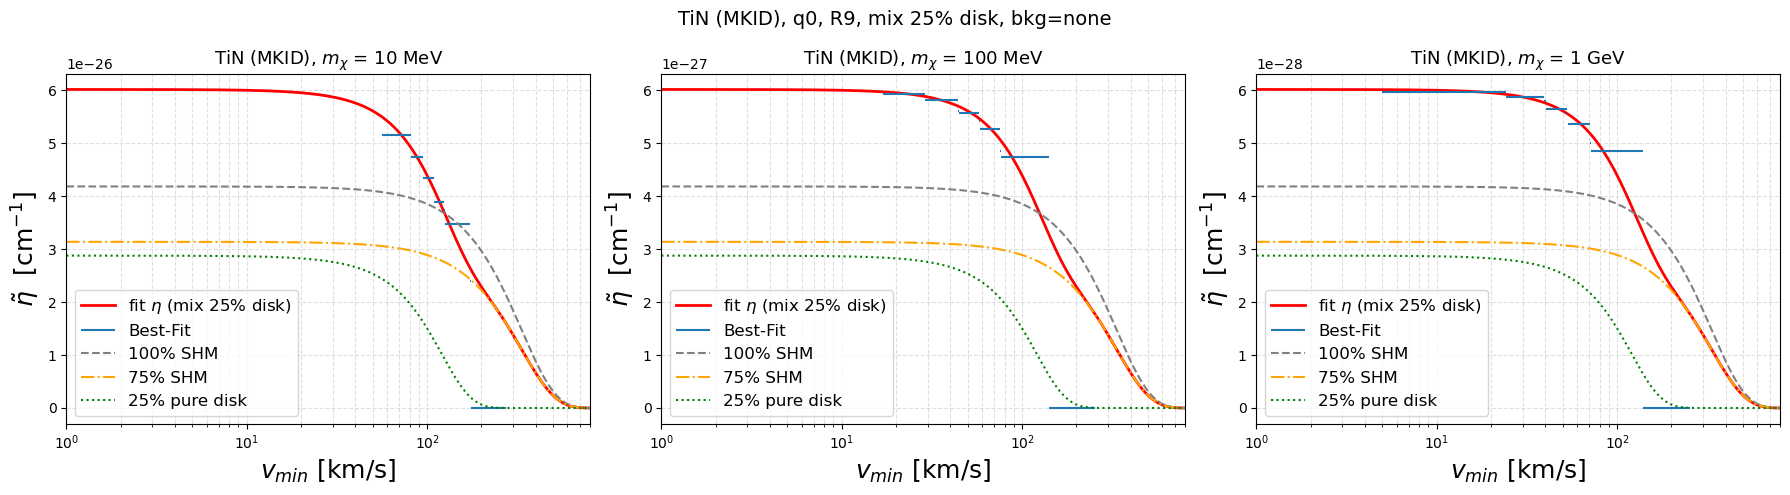

In [62]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=9, disk_fraction=p)

### Light mediator (q2), 9 energy bins

signal     : [10261.92393529 12819.08894258 14823.55733051 16435.68871989
 17601.0968527  18522.78581698 19185.2771624  19643.00945266
 19911.00106103]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_mix5/flux.pdf
TiN q2 M1 R9: 9 E-bins x 893 v_min bins, peak flux 8.50e-31
signal     : [ 974.41450675 1230.34974432 1439.17069164 1607.07312469 1741.15255556
 1846.50060227 1927.79770265 1987.34007338 2028.68730973]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_mix5/flux.pdf
TiN q2 M2 R9: 9 E-bins x 941 v_min bins, peak flux 9.00e-32
signal     : [ 96.82293653 122.38217768 143.29951969 160.1740544  173.69902851
 184.37131375 192.6499163  198.75780913 203.04638806]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_a

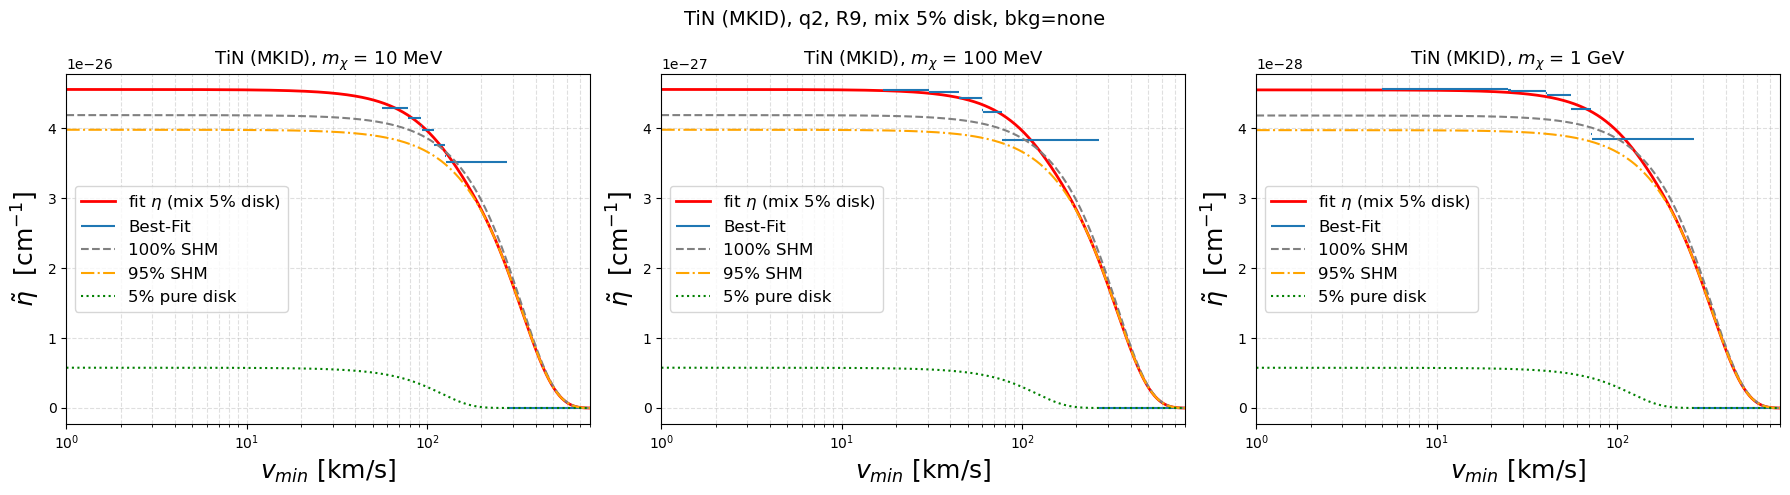

signal     : [11496.58763183 13669.06634306 15080.52810868 16024.16532653
 16509.6795472  16804.99152481 16916.86873563 16913.93936444
 16811.88121225]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_mix25/flux.pdf
TiN q2 M1 R9: 9 E-bins x 893 v_min bins, peak flux 1.04e-30
signal     : [1146.0430985  1398.5393673  1581.82432954 1709.7702904  1795.44525696
 1848.36483738 1876.40813274 1884.31087442 1877.29384523]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_mix25/flux.pdf
TiN q2 M2 R9: 9 E-bins x 941 v_min bins, peak flux 1.18e-31
signal     : [114.24793358 139.74786274 158.42154086 171.59755461 180.54094931
 186.17439841 189.26846304 190.28634447 189.74839592]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor

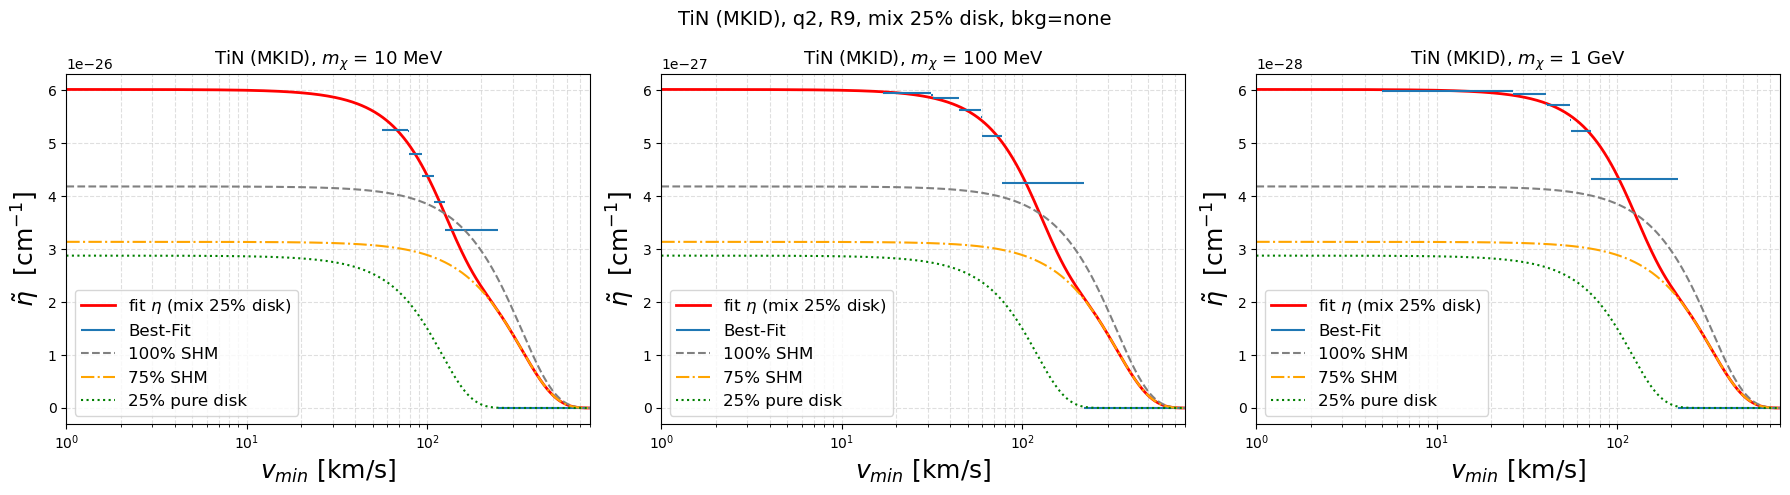

In [67]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=9, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [6.55781086e+09 9.72961759e+07 3.17588214e+04 8.36541616e+01
 9.03335132e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Bound/flux.pdf
TiN q0 M3 R5: 5 E-bins x 298 v_min bins, peak flux 7.63e-20


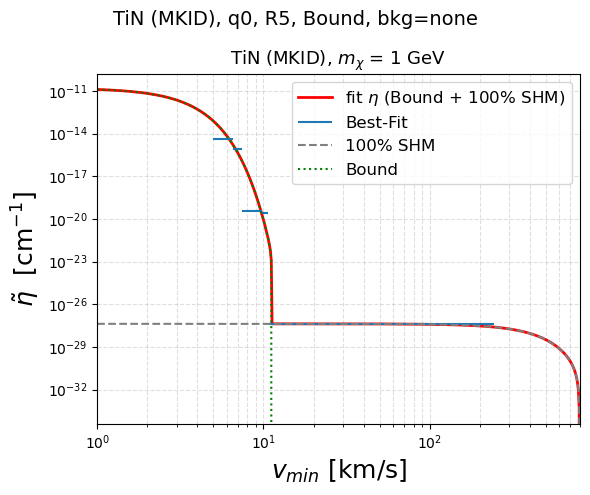

In [63]:
run_masses('TiN', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [3.15490637e+07 1.36128581e+05 3.26313656e+02 3.60245941e+02
 3.88721609e+02]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Bound/flux.pdf
TiN q2 M3 R5: 5 E-bins x 955 v_min bins, peak flux 2.25e-20


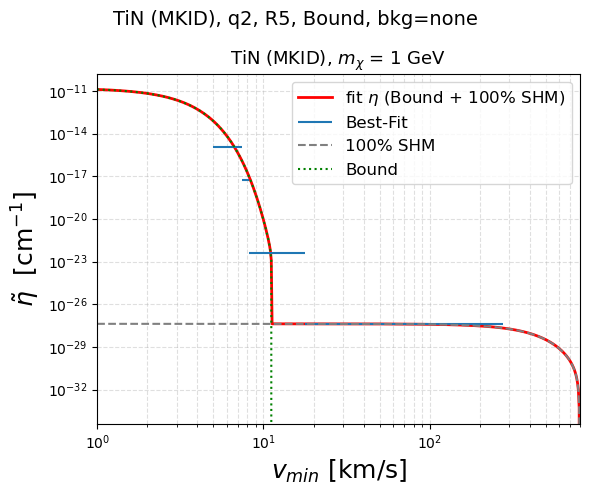

In [64]:
run_masses('TiN', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 9 energy bins

signal     : [6.55781086e+09 9.63104016e+07 1.51864704e+06 3.13013018e+04
 6.32894383e+02 4.59807323e+01 4.12945420e+01 4.53458798e+01
 4.92863602e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Bound/flux.pdf
TiN q0 M3 R9: 9 E-bins x 311 v_min bins, peak flux 8.14e-20


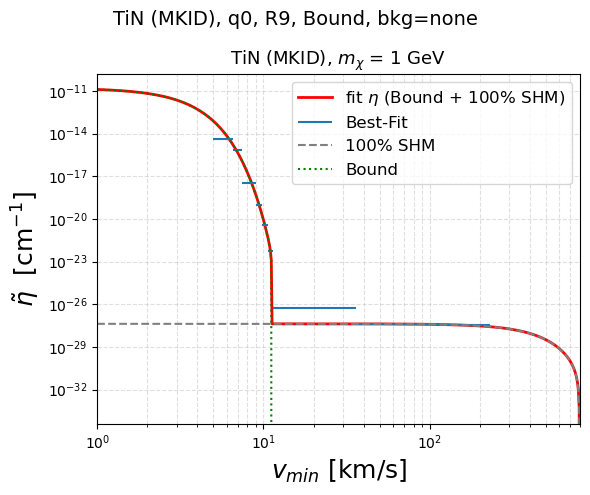

In [65]:
run_masses('TiN', q='0', nbins=9, eta='Bound', masses=('3',))

### Light mediator (q2), 9 energy bins

signal     : [3.15490637e+07 1.35334117e+05 1.22484842e+03 1.69199797e+02
 1.72154210e+02 1.83922262e+02 1.93495289e+02 2.00875675e+02
 2.06370886e+02]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R9_Bound/flux.pdf
TiN q2 M3 R9: 9 E-bins x 956 v_min bins, peak flux 4.16e-20


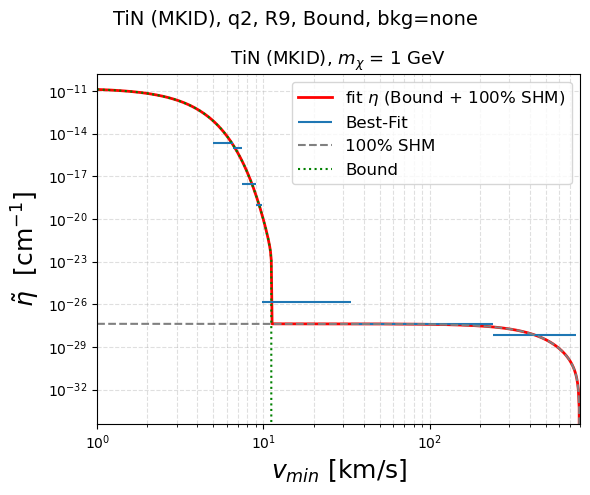

In [68]:
run_masses('TiN', q='2', nbins=9, eta='Bound', masses=('3',))